# Phase 4 — Descriptive Analysis: Weather Data

Descriptive and summary-statistics exhibits:

- **Tier 1 — internal QA and exploratory exhibits:** establish that the panel is complete, plausible, and contains meaningful temporal and spatial variation. Outputs are fast & minimally-styled.
- **Tier 2 — polished explanatory exhibits:** communicate the project's core weather story: long-run winter warming and county-level anomalously warm winter shocks.

PRISM is the primary weather dataset. ERA5 is a secondary robustness source and does not require a fully duplicated polished exhibit suite unless a direct PRISM–ERA5 comparison is useful.

## 0. Setup, definitions, and analytical conventions

Establish paths, imports, dataset configuration, labels, output directories, and common plotting settings. Document all analytical conventions before generating exhibits.

Required conventions:

- Winter is December–February (months DJF), with December assigned to the following winter year.
- With PRISM beginning in January 1981, complete DJF winters span 1982–2025.
- Construct one observation per county-winter before producing winter exhibits.
- Sum day counts and accumulated totals across winter months.
- Calculate winter temperature means using an appropriate mean, preferably weighted by observed days.
- Treat monthly variances and state variables such as snow depth according to explicitly documented aggregation rules.
- Unless otherwise specified, national and state summaries are unweighted means across counties.
- Keep freezing days (`TMIN < 32°F`) separate from extreme-cold days (`TMIN < 0°F`).

In [1]:
from dataclasses import dataclass
from pathlib import Path
import calendar
import io
import os
import warnings

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import SVG, display
import numpy as np
import pandas as pd

# Make Matplotlib output render beneath each notebook cell while figures
# are also saved separately as vector PDFs.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass  # Allows the same helpers to run from a regular Python process.

def resolve_repo_root():
    """Resolve the project checkout on either Kodama or a local Mac.

    Unlike a .py file, a notebook has no reliable __file__. Jupyter's current
    working directory depends on how the server/editor was launched, so search
    plausible roots and accept the first directory with this repo's structure.
    Set COLLISIONS_WEATHER_ROOT to override discovery explicitly.
    """
    cwd = Path.cwd().resolve()
    candidates = []
    env_root = os.environ.get("COLLISIONS_WEATHER_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())
    # Prefer the documented production roots before generic cwd discovery.
    candidates.extend([
        Path("/mnt/data_d/Dropbox/Research/AnimalCollisionsWeather"),
        Path("/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate"),
    ])
    for base in (cwd, *cwd.parents):
        candidates.extend([
            base,
            base / "collisions-and-climate",
            base / "Repos" / "collisions-and-climate",
        ])
    checked = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in checked:
            continue
        checked.append(candidate)
        required = [
            candidate / "codePYTHON",
            candidate / "dataCSV" / "PRISM" / "prism_county_month.csv",
            candidate / "dataCSV" / "PRISM" / "prism_derived_weather_vars.csv",
        ]
        if required[0].is_dir() and all(path.is_file() for path in required[1:]):
            return candidate
    attempted = "\n  - ".join(str(path) for path in checked)
    raise FileNotFoundError(
        "Could not locate the collisions-and-climate project root. Checked:\n  - "
        + attempted
        + "\nSet COLLISIONS_WEATHER_ROOT to the project directory and rerun."
    )

REPO_ROOT = resolve_repo_root()
DATA_DIR = REPO_ROOT / "dataCSV"
TABLES_DIR = REPO_ROOT / "tables" / "weather" / "tier1"
FIGURES_DIR = REPO_ROOT / "figures" / "weather" / "tier1"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ID_COLS = ["geoid", "state_fips", "county_fips", "county_name"]
WINTER_MONTHS = (12, 1, 2)
EXPECTED_YEARS = set(range(1981, 2026))
PRIMARY_TREND_VARS = [
    "mean_temp_c",
    "days_extremely_cold",
    "days_below_freezing_32f",
    "freeze_thaw_days",
]
SPAGHETTI_VARS = ["mean_temp_c"]
OUTLIER_Z_THRESHOLD = 5.0

STATE_FIPS_TO_NAME = {
    "01":"Alabama","02":"Alaska","04":"Arizona","05":"Arkansas","06":"California",
    "08":"Colorado","09":"Connecticut","10":"Delaware","11":"District of Columbia",
    "12":"Florida","13":"Georgia","15":"Hawaii","16":"Idaho","17":"Illinois",
    "18":"Indiana","19":"Iowa","20":"Kansas","21":"Kentucky","22":"Louisiana",
    "23":"Maine","24":"Maryland","25":"Massachusetts","26":"Michigan",
    "27":"Minnesota","28":"Mississippi","29":"Missouri","30":"Montana",
    "31":"Nebraska","32":"Nevada","33":"New Hampshire","34":"New Jersey",
    "35":"New Mexico","36":"New York","37":"North Carolina","38":"North Dakota",
    "39":"Ohio","40":"Oklahoma","41":"Oregon","42":"Pennsylvania",
    "44":"Rhode Island","45":"South Carolina","46":"South Dakota",
    "47":"Tennessee","48":"Texas","49":"Utah","50":"Vermont","51":"Virginia",
    "53":"Washington","54":"West Virginia","55":"Wisconsin","56":"Wyoming",
}
VARIABLE_LABELS = {
    "mean_temp_c": "Mean winter temperature (°C)",
    "days_extremely_cold": "Extreme-cold days per winter (TMIN < 0°F)",
    "days_below_freezing_32f": "Freezing days per winter (TMIN < 32°F)",
    "freeze_thaw_days": "Freeze–thaw days per winter",
    "ppt_total": "Total precipitation (mm)",
    "heating_degree_days": "Heating degree days",
    "cooling_degree_days": "Cooling degree days",
}
VARIABLE_UNITS = {
    "mean_temp_c": "°C", "days_extremely_cold": "days",
    "days_below_freezing_32f": "days", "freeze_thaw_days": "days",
    "ppt_total": "mm", "heating_degree_days": "degree-days",
    "cooling_degree_days": "degree-days",
}

@dataclass(frozen=True)
class DatasetConfig:
    name: str
    monthly_path: Path
    derived_path: Path
    is_primary: bool = False

PRISM_CONFIG = DatasetConfig(
    "PRISM", DATA_DIR / "PRISM" / "prism_county_month.csv",
    DATA_DIR / "PRISM" / "prism_derived_weather_vars.csv", True,
)
ERA5_CONFIG = DatasetConfig(
    "ERA5", DATA_DIR / "ERA5" / "era5_county_month.csv",
    DATA_DIR / "ERA5" / "era5_derived_weather_vars.csv", False,
)
config = PRISM_CONFIG
print(f"Dataset: {config.name}")
print(f"Repository root: {REPO_ROOT}")
print(f"Monthly input: {config.monthly_path}")
print(f"Derived input: {config.derived_path}")
print(f"Table outputs: {TABLES_DIR}")
print(f"Figure outputs: {FIGURES_DIR}")

def variable_label(variable):
    return VARIABLE_LABELS.get(variable, variable.replace("_", " ").title())

def state_label(fips):
    code = str(fips).zfill(2)
    return f"{code} — {STATE_FIPS_TO_NAME.get(code, '(unmapped)')}"

def display_figure_inline(fig):
    """Embed a vector SVG in notebook output, independent of backend."""
    buffer = io.StringIO()
    fig.savefig(buffer, format="svg", bbox_inches="tight")
    display(SVG(data=buffer.getvalue()))
    buffer.close()

def save_figure_pdf(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, format="pdf", bbox_inches="tight")
    display_figure_inline(fig)
    plt.close(fig)
    print(f"Saved {path}")
    return path

def _format_table_values(table):
    formatted_table = table.copy()
    for col in formatted_table.select_dtypes(include="number"):
        formatted_table[col] = formatted_table[col].map(
            lambda x: "" if pd.isna(x) else f"{x:,.3f}" if not float(x).is_integer() else f"{x:,.0f}"
        )
    return formatted_table

def save_table_pdf(table, path, title, rows_per_page=32, fontsize=7):
    """Save a DataFrame as one or more vector-PDF table pages."""
    formatted_table = _format_table_values(table)
    with PdfPages(path) as pdf:
        for start in range(0, max(len(formatted_table), 1), rows_per_page):
            page = formatted_table.iloc[start:start + rows_per_page]
            fig_height = max(3.0, 0.30 * (len(page) + 4))
            fig, ax = plt.subplots(figsize=(7.5, fig_height))
            ax.axis("off")
            ax.set_title(title, loc="left", fontsize=12, pad=12)
            if page.empty:
                ax.text(
                    0.01, 0.88,
                    "No rows available. Check the preceding sample-construction diagnostics.",
                    transform=ax.transAxes, ha="left", va="top", fontsize=10,
                )
                pdf.savefig(fig, bbox_inches="tight")
                display_figure_inline(fig)
                plt.close(fig)
                continue
            artist = ax.table(
                cellText=page.values, colLabels=page.columns,
                loc="upper left", cellLoc="right", colLoc="center",
                bbox=[0, 0, 1, 0.94],
            )
            artist.auto_set_font_size(False)
            artist.set_fontsize(fontsize)
            artist.auto_set_column_width(col=list(range(len(page.columns))))
            pdf.savefig(fig, bbox_inches="tight")
            display_figure_inline(fig)
            plt.close(fig)
    print(f"Saved {path}")
    return path

Dataset: PRISM
Repository root: /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate
Monthly input: /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/dataCSV/PRISM/prism_county_month.csv
Derived input: /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/dataCSV/PRISM/prism_derived_weather_vars.csv
Table outputs: /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1
Figure outputs: /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1


## 1. Load and validate the county-year-month panel

Load the raw monthly and derived-variable files, verify key uniqueness, compare overlapping QA fields, and merge on county, year, and month. Preserve clear diagnostics for duplicates, unmatched rows, missing values, and incomplete months.

In [2]:
def load_weather_panel(dataset_config):
    dtype = {"geoid": str, "state_fips": str, "county_fips": str}
    monthly = pd.read_csv(dataset_config.monthly_path, dtype=dtype)
    derived = pd.read_csv(dataset_config.derived_path, dtype=dtype)

    keys = ["geoid", "year", "month"]
    duplicate_monthly = int(monthly.duplicated(keys).sum())
    duplicate_derived = int(derived.duplicated(keys).sum())
    if duplicate_monthly or duplicate_derived:
        raise ValueError(
            f"Duplicate keys: monthly={duplicate_monthly:,}, derived={duplicate_derived:,}"
        )

    redundant_ids = [c for c in ID_COLS if c != "geoid"]
    qa_cols = [
        c for c in ("n_days", "expected_days", "is_incomplete", "dataset_types")
        if c in monthly.columns and c in derived.columns
    ]
    qa_mismatches = {}
    if qa_cols:
        check = monthly[keys + qa_cols].merge(
            derived[keys + qa_cols], on=keys, how="inner",
            suffixes=("_monthly", "_derived"), validate="one_to_one",
        )
        for col in qa_cols:
            left, right = check[f"{col}_monthly"], check[f"{col}_derived"]
            qa_mismatches[col] = int((left.fillna("<NA>") != right.fillna("<NA>")).sum())

    slim = derived.drop(columns=redundant_ids + qa_cols, errors="ignore")
    merged = monthly.merge(
        slim, on=keys, how="outer", indicator=True, validate="one_to_one"
    )
    merge_counts = merged["_merge"].value_counts().to_dict()
    merged = merged.drop(columns="_merge")

    diagnostics = {
        "dataset": dataset_config.name,
        "monthly_rows": len(monthly),
        "derived_rows": len(derived),
        "merged_rows": len(merged),
        "counties": merged["geoid"].nunique(),
        "first_year": int(merged["year"].min()),
        "last_year": int(merged["year"].max()),
        "duplicate_monthly_keys": duplicate_monthly,
        "duplicate_derived_keys": duplicate_derived,
        "monthly_only_rows": int(merge_counts.get("left_only", 0)),
        "derived_only_rows": int(merge_counts.get("right_only", 0)),
        "incomplete_months": int(merged.get("is_incomplete", pd.Series(False, index=merged.index)).fillna(False).sum()),
        **{f"qa_mismatch_{key}": value for key, value in qa_mismatches.items()},
    }
    if diagnostics["monthly_only_rows"] or diagnostics["derived_only_rows"]:
        warnings.warn("Monthly and derived files do not match completely; inspect coverage table.")
    return merged, diagnostics

df, load_diagnostics = load_weather_panel(config)
display(pd.DataFrame([load_diagnostics]))
display(df.head())

,dataset,monthly_rows,derived_rows,merged_rows,counties,first_year,last_year,duplicate_monthly_keys,duplicate_derived_keys,monthly_only_rows,derived_only_rows,incomplete_months,qa_mismatch_n_days,qa_mismatch_expected_days,qa_mismatch_is_incomplete,qa_mismatch_dataset_types
0,PRISM,74592,74592,74592,3108,2020,2021,0,0,0,0,0,0,0,0,0


,geoid,state_fips,county_fips,county_name,year,month,n_days,ppt_total,tmean_mean,tmin_mean,...,dataset_types,expected_days,is_incomplete,days_below_freezing,freeze_thaw_days,days_precip_gt_10mm,heating_degree_days,cooling_degree_days,mean_temp_c,tmean_variance_c2
0,01001,01,001,Autauga,2020,1,31,197.926575,9.849364,3.767306,...,AN81,31,False,10,10,7,263.627408,0.624353,9.849364,24.826668
1,01001,01,001,Autauga,2020,2,29,262.639709,11.104159,5.226372,...,AN81,29,False,6,6,9,213.331081,3.685032,11.104159,22.267492
2,01001,01,001,Autauga,2020,3,31,161.956354,17.803452,11.932944,...,AN81,31,False,0,0,3,65.613815,49.187483,17.803452,19.946408
3,01001,01,001,Autauga,2020,4,30,183.470696,16.808810,9.777331,...,AN81,30,False,0,0,3,65.160548,19.424855,16.808810,9.671948
4,01001,01,001,Autauga,2020,5,31,91.428339,20.955718,14.400450,...,AN81,31,False,0,0,4,22.231503,103.525438,20.955718,13.358260


## 2. Construct the county-winter panel

Convert the county-month panel into one observation per county-winter using variable-specific aggregation rules. Exclude or explicitly flag partial winters so that incomplete boundary years are not presented as full winters.

In [3]:
NON_WEATHER_COLS = {
    *ID_COLS, "year", "month", "winter_year", "n_days", "expected_days",
    "is_incomplete", "complete_winter", "dataset_types",
}
COUNT_OR_TOTAL_PATTERNS = (
    "days_", "heating_degree_days", "cooling_degree_days",
    "ppt_total", "total_snowfall",
)
VARIANCE_TO_MEAN = {
    "tmean_variance_c2": "tmean_mean",
    "tmin_variance_c2": "tmin_mean",
    "tmax_variance_c2": "tmax_mean",
}

def _numeric_weather_columns(frame):
    return [
        c for c in frame.columns
        if c not in NON_WEATHER_COLS and pd.api.types.is_numeric_dtype(frame[c])
    ]

def _is_total_variable(variable):
    return variable.startswith(COUNT_OR_TOTAL_PATTERNS)

def construct_county_winter_panel(monthly):
    """Collapse county-months to complete county-winters with vectorized rules."""
    work = monthly.copy()
    work["winter_year"] = work["year"] + (work["month"] == 12).astype(int)
    work = work[work["month"].isin(WINTER_MONTHS)].copy()

    group_keys = ID_COLS + ["winter_year"]
    completeness = (
        work.groupby(["geoid", "winter_year"], as_index=False)
        .agg(n_months=("month", "nunique"), observed_days=("n_days", "sum"))
    )
    completeness["expected_winter_days"] = completeness["winter_year"].map(
        lambda y: 31 + calendar.monthrange(int(y), 2)[1] + 31
    )
    completeness["complete_winter"] = (
        completeness["n_months"].eq(3)
        & completeness["observed_days"].eq(completeness["expected_winter_days"])
    )
    if "is_incomplete" in work:
        monthly_flags = (
            work.groupby(["geoid", "winter_year"], as_index=False)["is_incomplete"]
            .any().rename(columns={"is_incomplete": "has_flagged_month"})
        )
        completeness = completeness.merge(
            monthly_flags, on=["geoid", "winter_year"], validate="one_to_one"
        )
        completeness["complete_winter"] &= ~completeness["has_flagged_month"]

    complete = work.merge(
        completeness[["geoid", "winter_year", "complete_winter"]],
        on=["geoid", "winter_year"], validate="many_to_one",
    )
    complete = complete[complete["complete_winter"]].copy()
    grouped = complete.groupby(group_keys, sort=True, dropna=False)
    county_winter = grouped["n_days"].sum().rename("n_days").reset_index()

    variables = _numeric_weather_columns(complete)
    variance_vars = [v for v in VARIANCE_TO_MEAN if v in variables and VARIANCE_TO_MEAN[v] in complete]
    total_vars = [v for v in variables if _is_total_variable(v)]
    mean_vars = [v for v in variables if v not in total_vars and v not in variance_vars]

    # Counts and accumulated quantities are additive across Dec/Jan/Feb.
    if total_vars:
        totals = grouped[total_vars].sum(min_count=1).reset_index()
        county_winter = county_winter.merge(totals, on=group_keys, validate="one_to_one")

    # Monthly means are combined using observed county-month day counts.
    for variable in mean_vars:
        valid = complete[variable].notna() & complete["n_days"].gt(0)
        temp = complete.loc[valid, group_keys].copy()
        temp["_weighted_value"] = complete.loc[valid, variable] * complete.loc[valid, "n_days"]
        temp["_weight"] = complete.loc[valid, "n_days"]
        weighted = temp.groupby(group_keys, as_index=False)[["_weighted_value", "_weight"]].sum()
        weighted[variable] = weighted["_weighted_value"] / weighted["_weight"]
        county_winter = county_winter.merge(
            weighted[group_keys + [variable]], on=group_keys, how="left", validate="one_to_one"
        )

    # Combine monthly daily-sample variances exactly:
    # SS = sum[(n_m-1)s_m^2 + n_m*mean_m^2] - (sum[n_m*mean_m])^2/N.
    for variance_col in variance_vars:
        mean_col = VARIANCE_TO_MEAN[variance_col]
        valid = complete[[*group_keys, "n_days", mean_col, variance_col]].dropna()
        valid = valid[valid["n_days"].gt(0)].copy()
        valid["_sum_x"] = valid["n_days"] * valid[mean_col]
        valid["_sum_x2"] = (
            (valid["n_days"] - 1) * valid[variance_col]
            + valid["n_days"] * valid[mean_col].pow(2)
        )
        combined = (
            valid.groupby(group_keys, as_index=False)
            .agg(_n=("n_days", "sum"), _sum_x=("_sum_x", "sum"), _sum_x2=("_sum_x2", "sum"))
        )
        numerator = combined["_sum_x2"] - combined["_sum_x"].pow(2) / combined["_n"]
        combined[variance_col] = numerator.clip(lower=0) / (combined["_n"] - 1)
        combined.loc[combined["_n"].le(1), variance_col] = np.nan
        county_winter = county_winter.merge(
            combined[group_keys + [variance_col]],
            on=group_keys, how="left", validate="one_to_one"
        )

    winter_diagnostics = {
        "candidate_county_winters": len(completeness),
        "complete_county_winters": int(completeness["complete_winter"].sum()),
        "excluded_incomplete_county_winters": int((~completeness["complete_winter"]).sum()),
        "first_complete_winter": (
            int(county_winter["winter_year"].min()) if not county_winter.empty else None
        ),
        "last_complete_winter": (
            int(county_winter["winter_year"].max()) if not county_winter.empty else None
        ),
    }
    return county_winter, completeness, winter_diagnostics

county_winter, winter_completeness, winter_diagnostics = construct_county_winter_panel(df)
display(pd.DataFrame([winter_diagnostics]))
display(county_winter.head())

,candidate_county_winters,complete_county_winters,excluded_incomplete_county_winters,first_complete_winter,last_complete_winter
0,9324,3108,6216,2021,2021


,geoid,state_fips,county_fips,county_name,winter_year,n_days,ppt_total,days_below_freezing,days_precip_gt_10mm,heating_degree_days,cooling_degree_days,tmean_mean,tmin_mean,tmax_mean,tdmean_mean,vpdmin_mean,vpdmax_mean,freeze_thaw_days,mean_temp_c,tmean_variance_c2
0,01001,01,001,Autauga,2021,90,232.825806,42,7,919.524978,8.793200,8.214091,1.846770,14.614402,3.895718,0.332473,8.780798,14.033333,8.214091,24.675734
1,01003,01,003,Baldwin,2021,90,300.849059,20,11,728.554840,14.735487,10.402007,4.575654,16.332955,6.881076,0.323183,8.180465,6.655556,10.402007,24.704770
2,01005,01,005,Barbour,2021,90,311.341260,30,13,815.433916,8.239299,9.364504,3.168484,15.529573,4.829336,0.476117,8.997184,10.066667,9.364504,23.227488
3,01007,01,007,Bibb,2021,90,299.290562,47,10,979.921390,8.232839,7.536794,1.156981,13.917359,2.942364,0.393394,8.720141,15.377778,7.536794,25.752380
4,01009,01,009,Blount,2021,90,400.300352,50,11,1122.281707,2.625003,5.892703,-0.051682,11.756744,1.728894,0.365128,7.053838,16.377778,5.892703,23.580695


# Tier 1 — Internal QA and exploratory exhibits

Tier 1 checks whether the weather panel is complete, internally coherent, and within plausible ranges. It also establishes whether the data contain meaningful variation across counties, states, and winters. These exhibits are intended primarily for internal review.

## 3. Data coverage and integrity table

Report the dataset, observation period, number of counties, number of county-months and county-winters, missing or incomplete records, merge mismatches, duplicate keys, and complete DJF winters retained. This table establishes the analysis sample before any substantive summaries are interpreted.

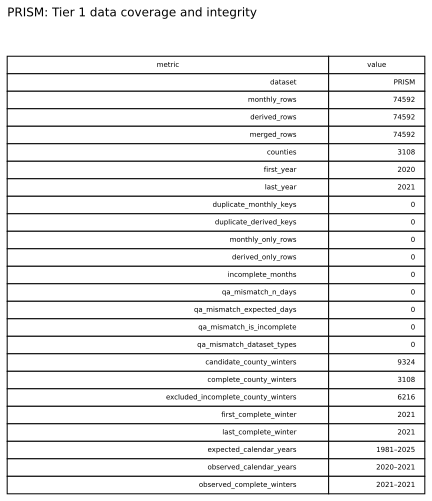

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1/prism_tier1_coverage_integrity.pdf


,metric,value
0,dataset,PRISM
1,monthly_rows,74592
2,derived_rows,74592
3,merged_rows,74592
4,counties,3108
5,first_year,2020
6,last_year,2021
7,duplicate_monthly_keys,0
8,duplicate_derived_keys,0
9,monthly_only_rows,0


In [4]:
coverage = {
    **load_diagnostics,
    **winter_diagnostics,
    "expected_calendar_years": f"{min(EXPECTED_YEARS)}–{max(EXPECTED_YEARS)}",
    "observed_calendar_years": f"{df['year'].min()}–{df['year'].max()}",
    "observed_complete_winters": (
        f"{county_winter['winter_year'].min()}–{county_winter['winter_year'].max()}"
    ),
}
coverage_table = pd.DataFrame(
    [{"metric": key, "value": value} for key, value in coverage.items()]
)
coverage_table.to_csv(TABLES_DIR / f"{config.name.lower()}_tier1_coverage_integrity.csv", index=False)
save_table_pdf(
    coverage_table,
    TABLES_DIR / f"{config.name.lower()}_tier1_coverage_integrity.pdf",
    f"{config.name}: Tier 1 data coverage and integrity",
)
display(coverage_table)

## 4. Pooled summary-statistics table

For every raw and derived weather variable, report the unit, observation count, mean, standard deviation, minimum, p1, p5, median, p95, p99, and maximum across all county-month observations. Use the tails to identify values that require investigation.

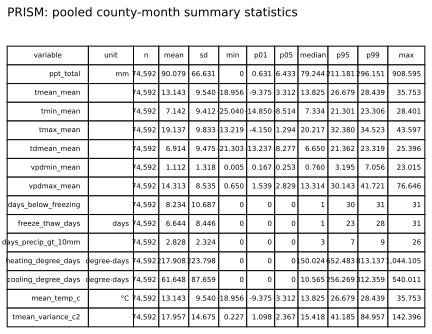

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1/prism_summary_pooled.pdf


,variable,unit,n,mean,sd,min,p01,p05,median,p95,p99,max
0,ppt_total,mm,74592,90.079128,66.631036,0.000000,0.630564,6.433270,79.244204,211.181131,296.151227,908.594720
1,tmean_mean,,74592,13.143236,9.539658,-18.956128,-9.374892,-3.312121,13.825254,26.679200,28.439205,35.753046
2,tmin_mean,,74592,7.142400,9.411820,-25.040312,-14.849708,-8.513986,7.333553,21.300877,23.306087,28.401070
3,tmax_mean,,74592,19.137183,9.832924,-13.218669,-4.150232,1.293550,20.216508,32.380380,34.523465,43.597101
4,tdmean_mean,,74592,6.913549,9.474914,-21.303370,-13.236513,-8.276994,6.649626,21.362083,23.319047,25.395875
5,vpdmin_mean,,74592,1.111956,1.317815,0.004785,0.166898,0.253211,0.760082,3.195080,7.055927,23.014601
6,vpdmax_mean,,74592,14.312820,8.534655,0.650497,1.538551,2.829062,13.314366,30.142511,41.720803,76.646234
7,days_below_freezing,,74592,8.234435,10.686603,0.000000,0.000000,0.000000,1.000000,30.000000,31.000000,31.000000
8,freeze_thaw_days,days,74592,6.643956,8.445636,0.000000,0.000000,0.000000,1.000000,23.000000,28.000000,31.000000
9,days_precip_gt_10mm,,74592,2.827864,2.323889,0.000000,0.000000,0.000000,3.000000,7.000000,9.000000,26.000000


In [5]:
SUMMARY_QUANTILES = [0.01, 0.05, 0.50, 0.95, 0.99]

def summarize_long(frame, group_cols=None):
    group_cols = list(group_cols or [])
    variables = _numeric_weather_columns(frame)
    records = []
    groups = [((), frame)] if not group_cols else frame.groupby(group_cols, dropna=False)
    for keys, group in groups:
        keys = keys if isinstance(keys, tuple) else (keys,)
        group_values = dict(zip(group_cols, keys))
        for variable in variables:
            values = group[variable].dropna()
            record = {
                **group_values,
                "variable": variable,
                "unit": VARIABLE_UNITS.get(variable, ""),
                "n": values.count(),
                "mean": values.mean(),
                "sd": values.std(),
                "min": values.min(),
                "p01": values.quantile(0.01),
                "p05": values.quantile(0.05),
                "median": values.quantile(0.50),
                "p95": values.quantile(0.95),
                "p99": values.quantile(0.99),
                "max": values.max(),
            }
            records.append(record)
    return pd.DataFrame(records)

summary_pooled = summarize_long(df)
summary_pooled.to_csv(TABLES_DIR / f"{config.name.lower()}_summary_pooled.csv", index=False)
save_table_pdf(
    summary_pooled,
    TABLES_DIR / f"{config.name.lower()}_summary_pooled.pdf",
    f"{config.name}: pooled county-month summary statistics",
    rows_per_page=24,
)
display(summary_pooled)

## 5. Monthly summary-statistics table

Report the same statistics separately by calendar month. This reveals expected seasonality and helps identify month-specific values that are implausible or inconsistent with neighboring months.

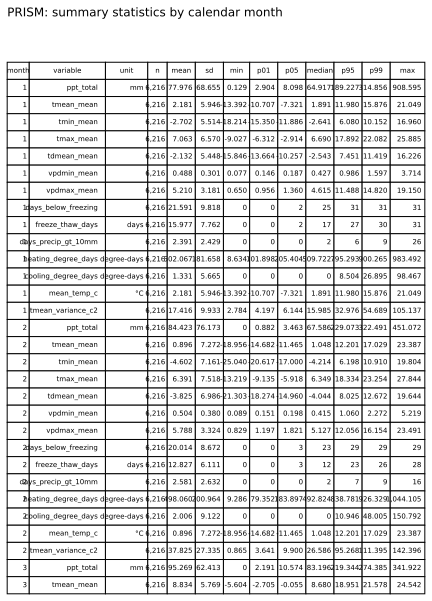

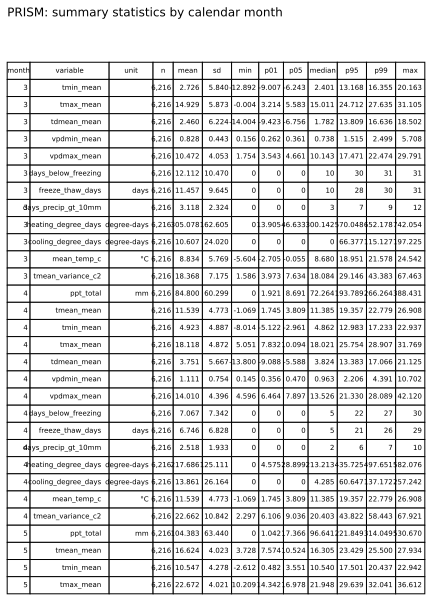

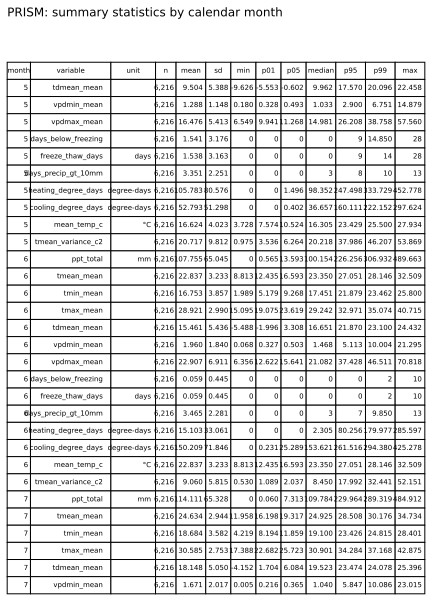

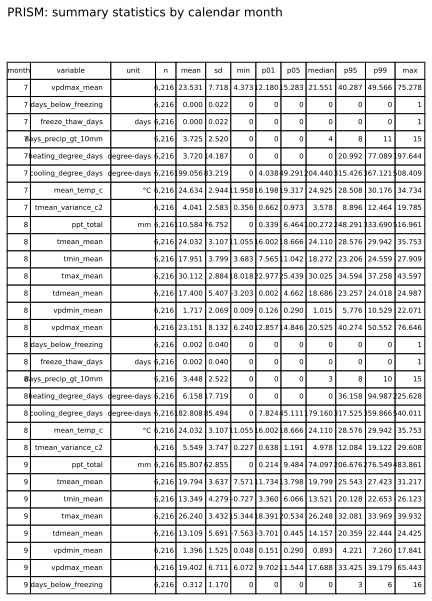

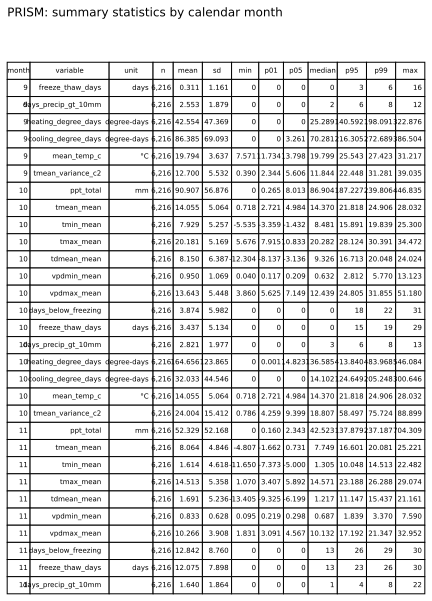

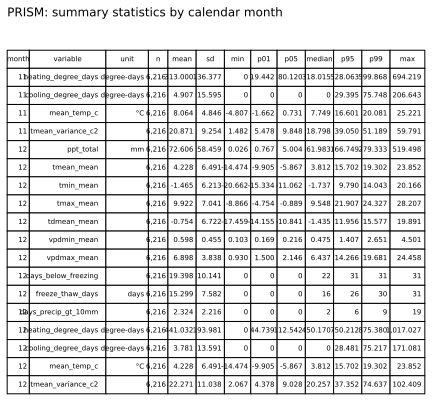

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1/prism_summary_by_calendar_month.pdf


,month,variable,unit,n,mean,sd,min,p01,p05,median,p95,p99,max
0,1,ppt_total,mm,6216,77.976092,68.654647,0.129220,2.903949,8.098295,64.916683,189.227271,314.855911,908.594720
1,1,tmean_mean,,6216,2.180569,5.945980,-13.392207,-10.707458,-7.321285,1.890675,11.980348,15.875774,21.049087
2,1,tmin_mean,,6216,-2.701509,5.513862,-18.213967,-15.349717,-11.886469,-2.640857,6.079674,10.152395,16.960458
3,1,tmax_mean,,6216,7.063053,6.570270,-9.027427,-6.311859,-2.913504,6.690202,17.891626,22.081562,25.884577
4,1,tdmean_mean,,6216,-2.131977,5.448104,-15.845830,-13.664202,-10.256567,-2.542659,7.451223,11.419194,16.226163
5,1,vpdmin_mean,,6216,0.487836,0.301404,0.076648,0.145764,0.186630,0.427077,0.986130,1.596791,3.713821
6,1,vpdmax_mean,,6216,5.210063,3.181440,0.650497,0.955963,1.360456,4.615358,11.488152,14.820378,19.149519
7,1,days_below_freezing,,6216,21.591216,9.818156,0.000000,0.000000,2.000000,25.000000,31.000000,31.000000,31.000000
8,1,freeze_thaw_days,days,6216,15.976995,7.761755,0.000000,0.000000,2.000000,17.000000,27.000000,30.000000,31.000000
9,1,days_precip_gt_10mm,,6216,2.390927,2.428778,0.000000,0.000000,0.000000,2.000000,6.000000,9.000000,26.000000


In [6]:
summary_by_month = summarize_long(df, ["month"])
summary_by_month.to_csv(
    TABLES_DIR / f"{config.name.lower()}_summary_by_calendar_month.csv", index=False
)
save_table_pdf(
    summary_by_month,
    TABLES_DIR / f"{config.name.lower()}_summary_by_calendar_month.pdf",
    f"{config.name}: summary statistics by calendar month",
    rows_per_page=30,
)
display(summary_by_month.head(24))

## 6. County summary-statistics table

Calculate summary statistics separately by county. Save the complete table as a machine-readable file; show only selected examples and counties flagged by transparent outlier rules in the rendered report.

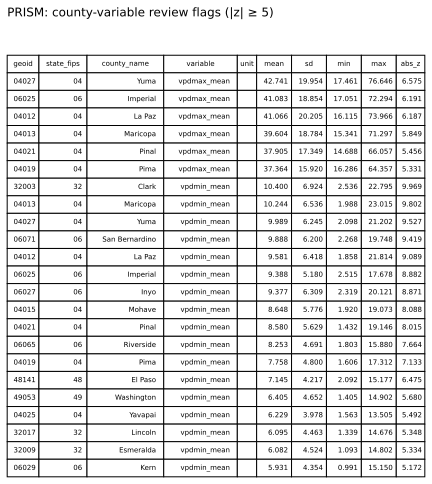

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1/prism_summary_by_county_review_flags.pdf


,geoid,state_fips,county_name,variable,unit,mean,sd,min,max,abs_z
1140,04027,04,Yuma,vpdmax_mean,,42.741303,19.953606,17.461394,76.646234,6.574816
2372,06025,06,Imperial,vpdmax_mean,,41.083453,18.853769,17.051382,72.294102,6.191395
1028,04012,04,La Paz,vpdmax_mean,,41.065949,20.204932,16.114709,73.966445,6.187347
1042,04013,04,Maricopa,vpdmax_mean,,39.603676,18.784031,15.341221,71.296905,5.849159
1098,04021,04,Pinal,vpdmax_mean,,37.905326,17.348872,14.688183,66.057385,5.456372
1084,04019,04,Pima,vpdmax_mean,,37.364083,15.919952,16.285955,64.356847,5.331196
24001,32003,32,Clark,vpdmin_mean,,10.400051,6.924205,2.535874,22.795347,9.968500
1041,04013,04,Maricopa,vpdmin_mean,,10.244500,6.535519,1.988443,23.014601,9.801554
1139,04027,04,Yuma,vpdmin_mean,,9.988558,6.245409,2.098328,21.202068,9.526863
2693,06071,06,San Bernardino,vpdmin_mean,,9.888339,6.199979,2.267645,19.748059,9.419303


In [7]:
summary_by_county = summarize_long(df, ["geoid"])
county_names = df[["geoid", "state_fips", "county_name"]].drop_duplicates("geoid")
summary_by_county = summary_by_county.merge(county_names, on="geoid", how="left", validate="many_to_one")
summary_by_county.to_csv(
    TABLES_DIR / f"{config.name.lower()}_summary_by_county.csv", index=False
)

# Flag county-variable means that are unusually far from the national
# distribution of county means. These are review flags, not automatic errors.
county_mean_distribution = (
    summary_by_county.groupby("variable")["mean"]
    .agg(mean_across_counties="mean", std_across_counties="std")
)
flagged_counties = summary_by_county.merge(
    county_mean_distribution, left_on="variable", right_index=True,
)
flagged_counties["abs_z"] = (
    (flagged_counties["mean"] - flagged_counties["mean_across_counties"])
    / flagged_counties["std_across_counties"]
).abs()
flagged_counties = flagged_counties[
    flagged_counties["abs_z"].ge(OUTLIER_Z_THRESHOLD)
].sort_values(["variable", "abs_z"], ascending=[True, False])
flagged_counties.to_csv(
    TABLES_DIR / f"{config.name.lower()}_summary_by_county_review_flags.csv", index=False
)
flag_columns = ["geoid", "state_fips", "county_name", "variable", "unit", "mean", "sd", "min", "max", "abs_z"]
save_table_pdf(
    flagged_counties[flag_columns],
    TABLES_DIR / f"{config.name.lower()}_summary_by_county_review_flags.pdf",
    f"{config.name}: county-variable review flags (|z| ≥ {OUTLIER_Z_THRESHOLD:g})",
    rows_per_page=28,
)
display(flagged_counties[flag_columns].head(30))

## 7. National winter-trend figures

Plot the annual unweighted county mean and the full-period linear trend for each principal winter measure:

1. Mean winter temperature
2. Extreme-cold-day count (`TMIN < 0°F`)
3. Freezing-day count (`TMIN < 32°F`)
4. Freeze–thaw-day count

Show annual values so that common shocks remain visible; the fitted trend should supplement rather than replace them.

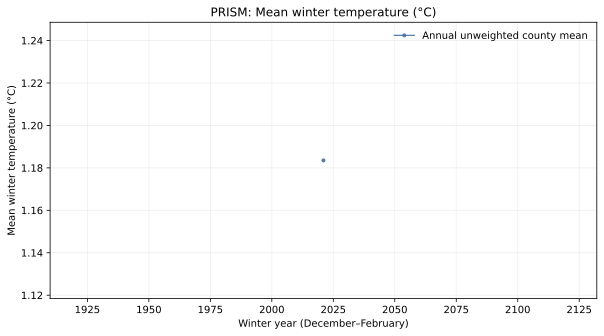

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1/prism_national_trend_mean_temp_c.pdf


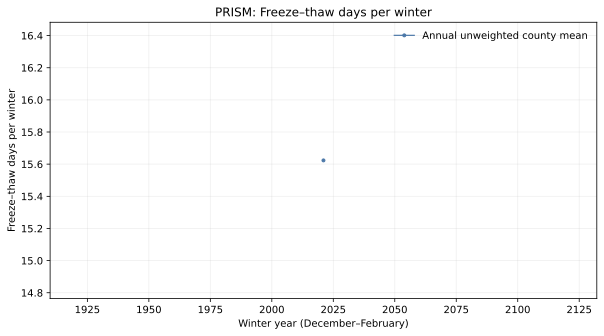

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1/prism_national_trend_freeze_thaw_days.pdf


In [8]:
def _linear_trend(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid["x"].nunique() < 2:
        return None
    slope, intercept = np.polyfit(valid["x"], valid["y"], 1)
    x_line = np.array([valid["x"].min(), valid["x"].max()])
    return x_line, intercept + slope * x_line, slope

def plot_national_winter_trend(frame, variable):
    annual = frame.groupby("winter_year", as_index=False)[variable].mean()
    trend = _linear_trend(annual["winter_year"], annual[variable])
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.plot(annual["winter_year"], annual[variable], color="#4C78A8", lw=1.2, marker="o", ms=3,
            label="Annual unweighted county mean")
    if trend is not None:
        ax.plot(trend[0], trend[1], color="black", lw=2, ls="--",
                label=f"Linear trend ({trend[2]:+.3f} per year)")
    ax.set(title=f"{config.name}: {variable_label(variable)}",
           xlabel="Winter year (December–February)", ylabel=variable_label(variable))
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    fig.tight_layout()
    return save_figure_pdf(fig, f"{config.name.lower()}_national_trend_{variable}.pdf")

national_trend_paths = [
    plot_national_winter_trend(county_winter, variable)
    for variable in PRIMARY_TREND_VARS if variable in county_winter
]

## 8. State winter-trend small multiples

Plot annual state means and full-period linear trends for the four principal winter measures, faceted by state. These figures assess geographic heterogeneity in levels, trends, and year-to-year movement. Use multi-page layouts when necessary for legibility.

**Findings:**
- Some linear trends for extreme-cold days approach or cross below zero by the end of the sample, implying impossible predicted values of "negative # of cold days." Which is acceptable for basic descriptive stats & internal QA (but not polished exhibits). 

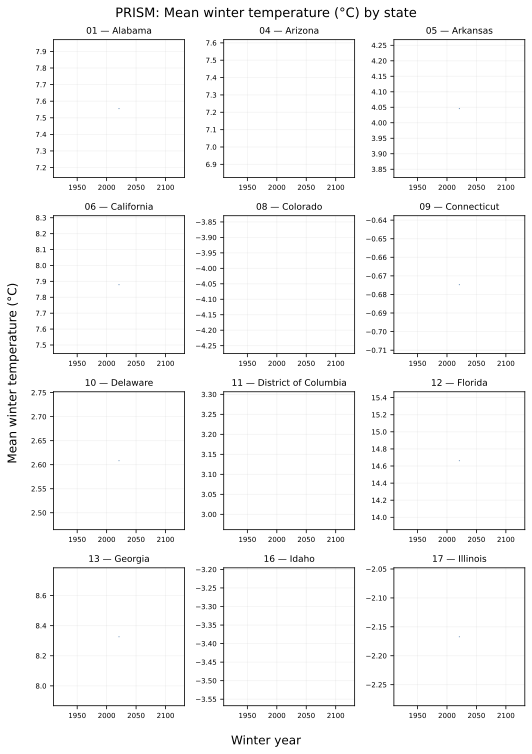

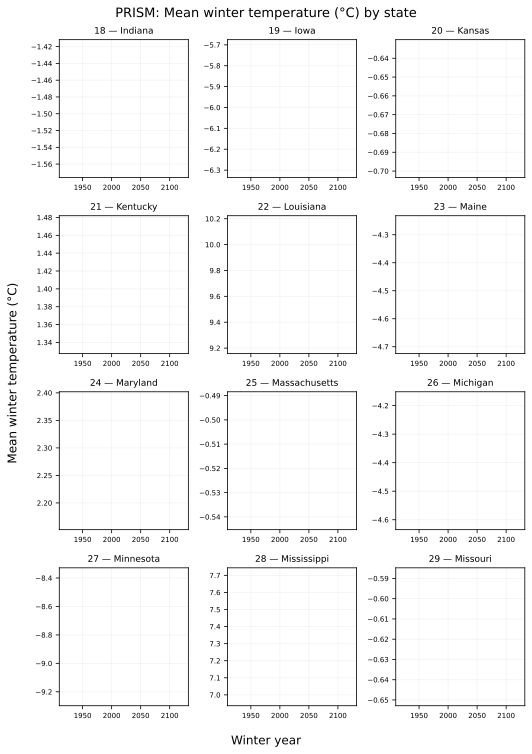

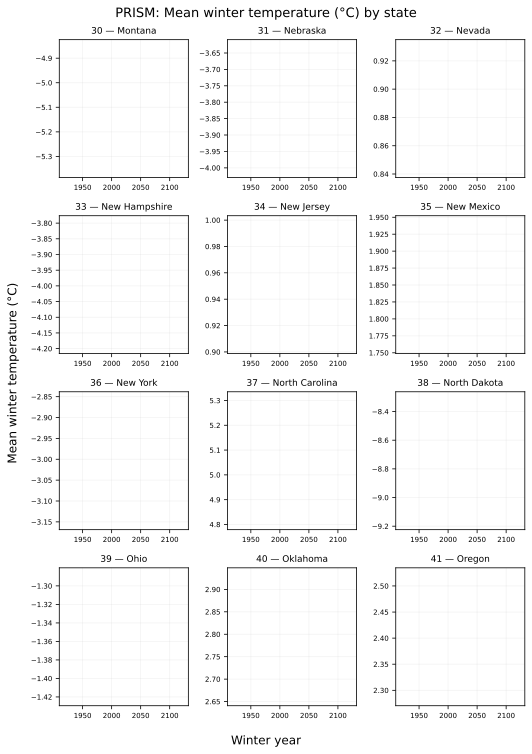

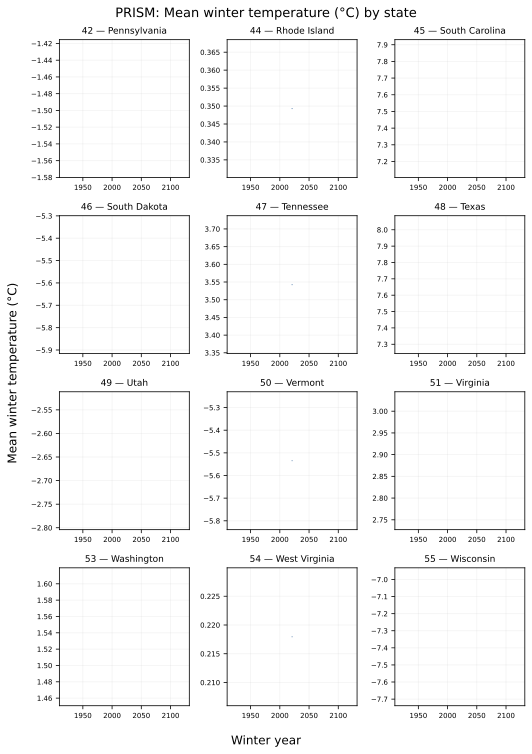

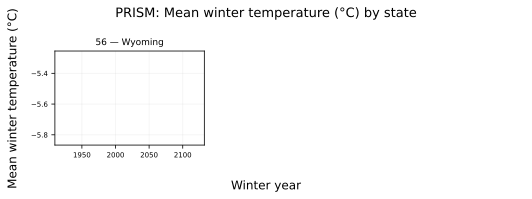

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1/prism_state_trends_mean_temp_c.pdf


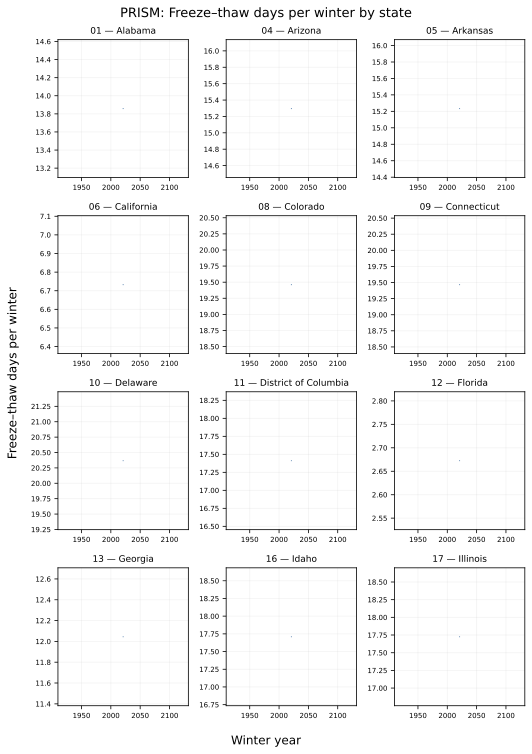

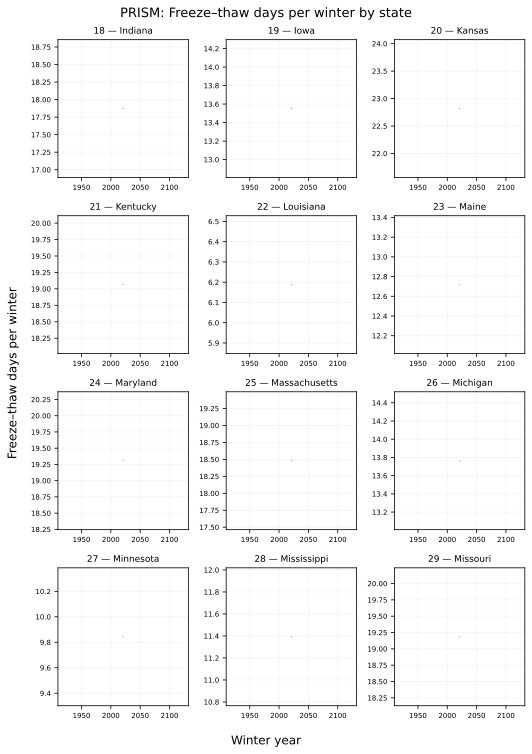

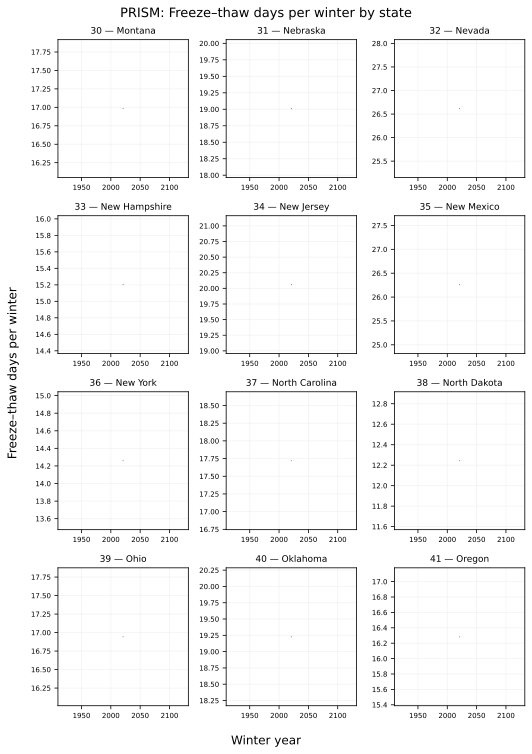

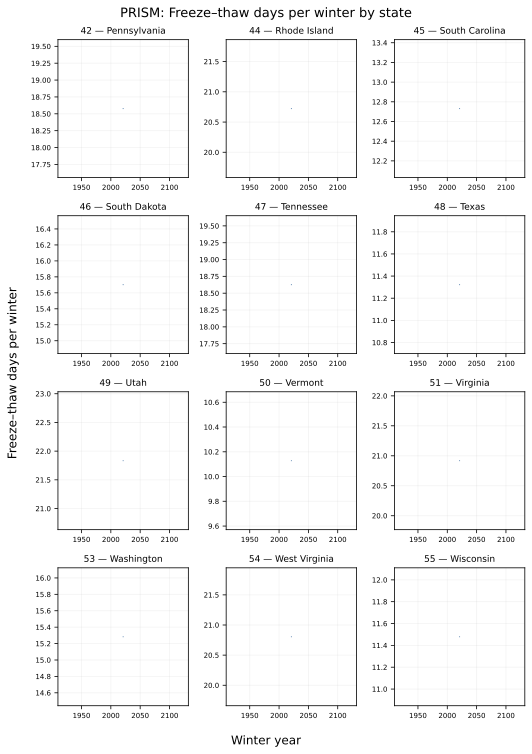

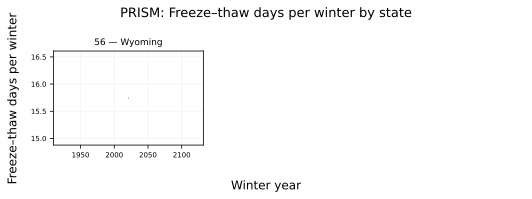

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1/prism_state_trends_freeze_thaw_days.pdf


In [9]:
def save_state_trend_multipage(frame, variable, states_per_page=12, n_cols=3):
    states = sorted(frame["state_fips"].dropna().unique())
    path = FIGURES_DIR / f"{config.name.lower()}_state_trends_{variable}.pdf"
    with PdfPages(path) as pdf:
        for start in range(0, len(states), states_per_page):
            page_states = states[start:start + states_per_page]
            n_rows = int(np.ceil(len(page_states) / n_cols))
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5, 2.65 * n_rows), squeeze=False)
            for ax, state in zip(axes.flat, page_states):
                annual = (
                    frame[frame["state_fips"].eq(state)]
                    .groupby("winter_year", as_index=False)[variable].mean()
                )
                trend = _linear_trend(annual["winter_year"], annual[variable])
                ax.plot(annual["winter_year"], annual[variable], color="#4C78A8", lw=0.9)
                if trend is not None:
                    ax.plot(trend[0], trend[1], color="black", lw=1.4, ls="--")
                ax.set_title(state_label(state), fontsize=9)
                ax.tick_params(labelsize=7)
                ax.grid(alpha=0.15)
            for ax in list(axes.flat)[len(page_states):]:
                ax.axis("off")
            fig.suptitle(f"{config.name}: {variable_label(variable)} by state", fontsize=13)
            fig.supxlabel("Winter year")
            fig.supylabel(variable_label(variable))
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            display_figure_inline(fig)
            plt.close(fig)
    print(f"Saved {path}")
    return path

state_trend_paths = [
    save_state_trend_multipage(county_winter, variable)
    for variable in PRIMARY_TREND_VARS if variable in county_winter
]

## 9. County spaghetti plots by state

For each state, plot one thin, transparent line per county and a prominent annual state-mean line. Optionally add a distinct dashed linear trend. Use these figures to inspect within-county variation, between-county dispersion, common shocks, outliers, discontinuities, and changes in dispersion over time.

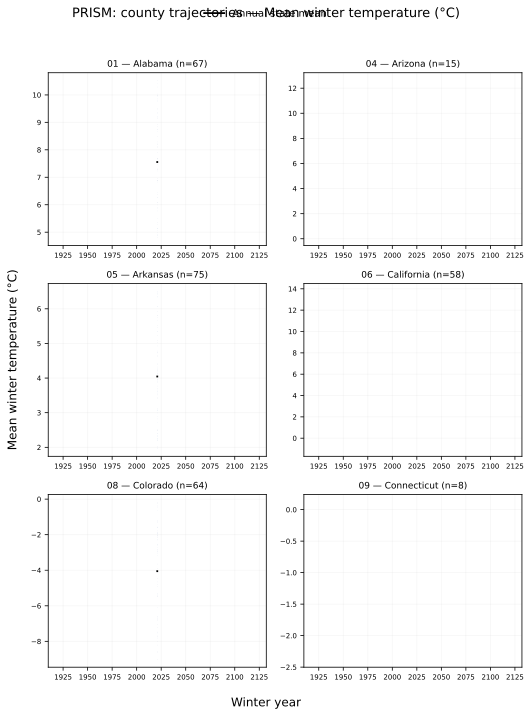

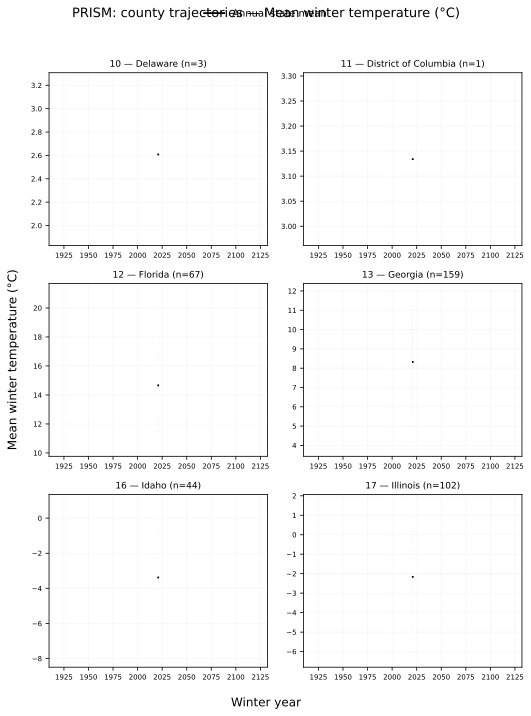

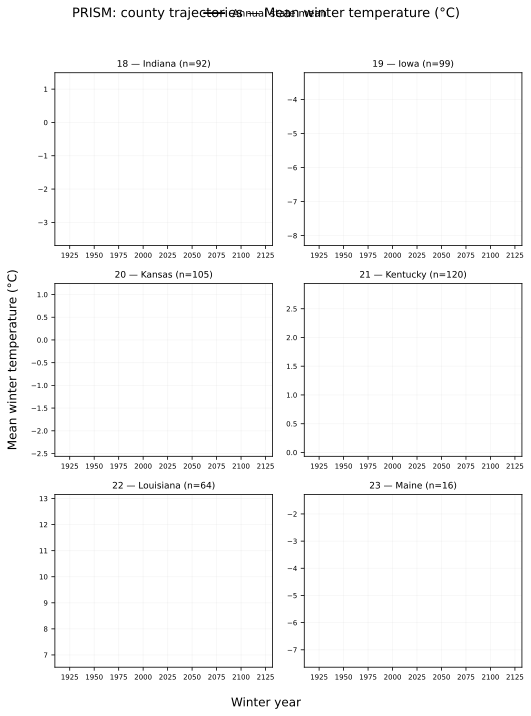

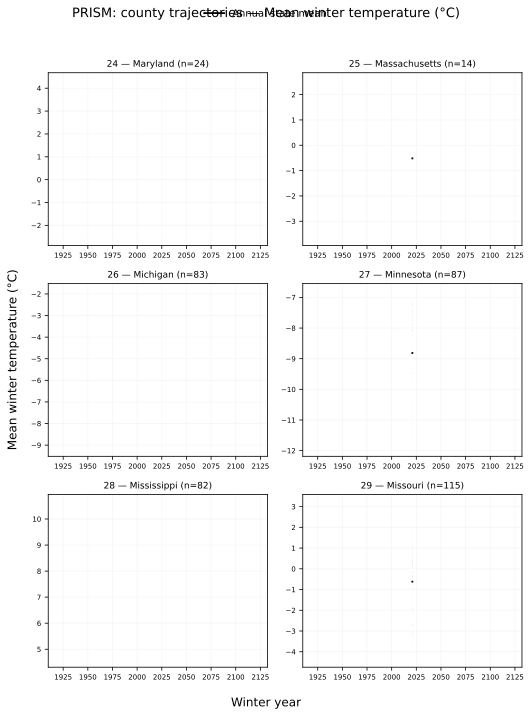

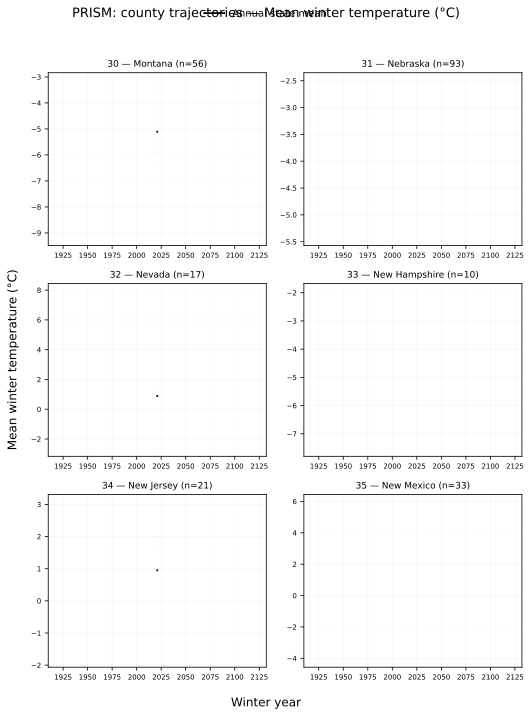

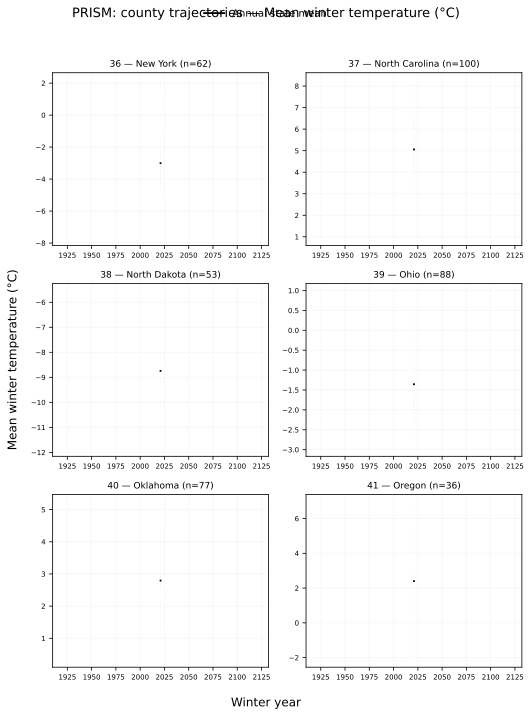

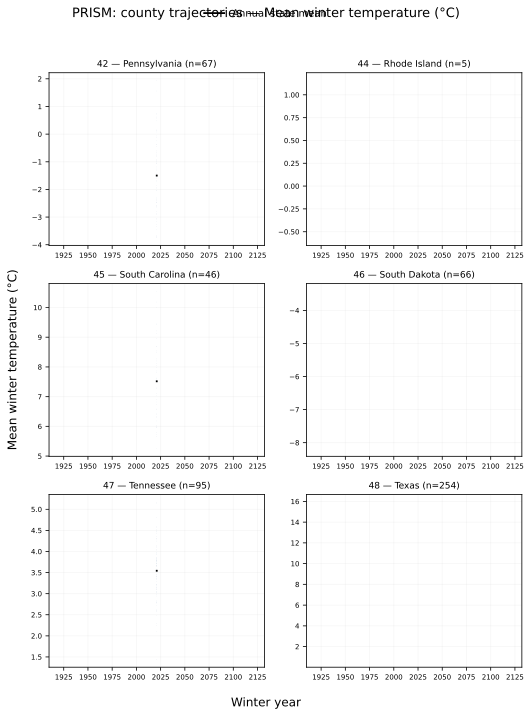

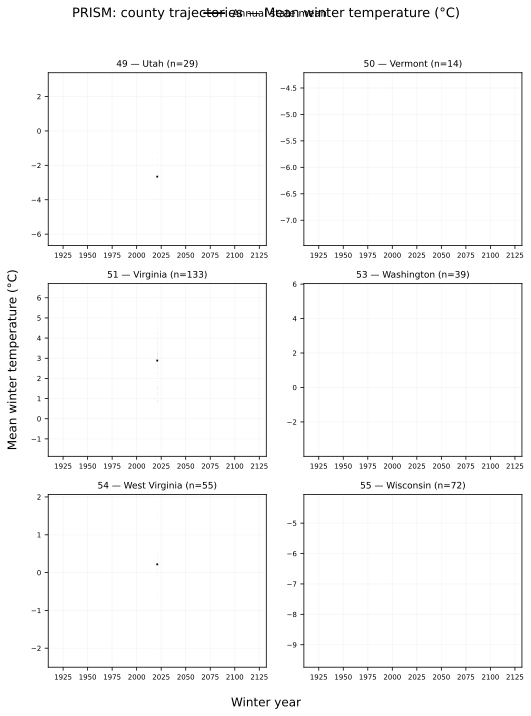

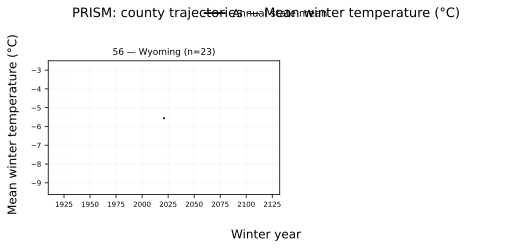

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1/prism_county_spaghetti_mean_temp_c.pdf


In [10]:
def save_spaghetti_multipage(frame, variable, states_per_page=6, n_cols=2):
    states = sorted(frame["state_fips"].dropna().unique())
    path = FIGURES_DIR / f"{config.name.lower()}_county_spaghetti_{variable}.pdf"
    with PdfPages(path) as pdf:
        for start in range(0, len(states), states_per_page):
            page_states = states[start:start + states_per_page]
            n_rows = int(np.ceil(len(page_states) / n_cols))
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5, 3.3 * n_rows), squeeze=False)
            for ax, state in zip(axes.flat, page_states):
                state_frame = frame[frame["state_fips"].eq(state)]
                for _, county in state_frame.groupby("geoid"):
                    county = county.sort_values("winter_year")
                    ax.plot(county["winter_year"], county[variable],
                            color="#4C78A8", alpha=0.18, lw=0.45)
                annual_mean = state_frame.groupby("winter_year", as_index=False)[variable].mean()
                ax.plot(annual_mean["winter_year"], annual_mean[variable],
                        color="black", lw=1.8, label="Annual state mean")
                trend = _linear_trend(annual_mean["winter_year"], annual_mean[variable])
                if trend is not None:
                    ax.plot(trend[0], trend[1], color="#E45756", lw=1.3, ls="--",
                            label="State linear trend")
                ax.set_title(f"{state_label(state)} (n={state_frame['geoid'].nunique()})", fontsize=9)
                ax.tick_params(labelsize=7)
                ax.grid(alpha=0.12)
            for ax in list(axes.flat)[len(page_states):]:
                ax.axis("off")
            handles, labels = axes.flat[0].get_legend_handles_labels()
            if handles:
                fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
            fig.suptitle(
                f"{config.name}: county trajectories — {variable_label(variable)}",
                fontsize=13, y=0.995,
            )
            fig.supxlabel("Winter year")
            fig.supylabel(variable_label(variable))
            fig.tight_layout(rect=[0, 0, 1, 0.97])
            pdf.savefig(fig, bbox_inches="tight")
            display_figure_inline(fig)
            plt.close(fig)
    print(f"Saved {path}")
    return path

spaghetti_paths = [
    save_spaghetti_multipage(county_winter, variable)
    for variable in SPAGHETTI_VARS if variable in county_winter
]

## 10. Decade-distribution plots by state

Compare county-level distributions of mean winter temperature across decades within each state. Use these exploratory plots to determine whether the distribution shifts in location, spread, or shape—not merely whether its mean changes.

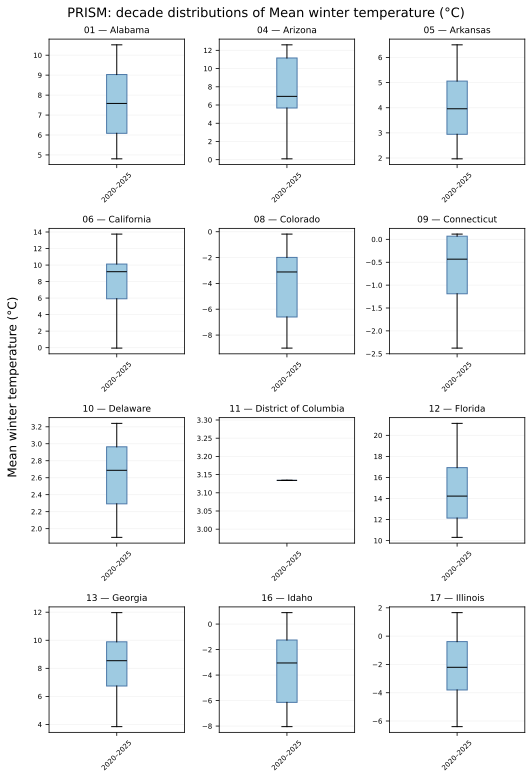

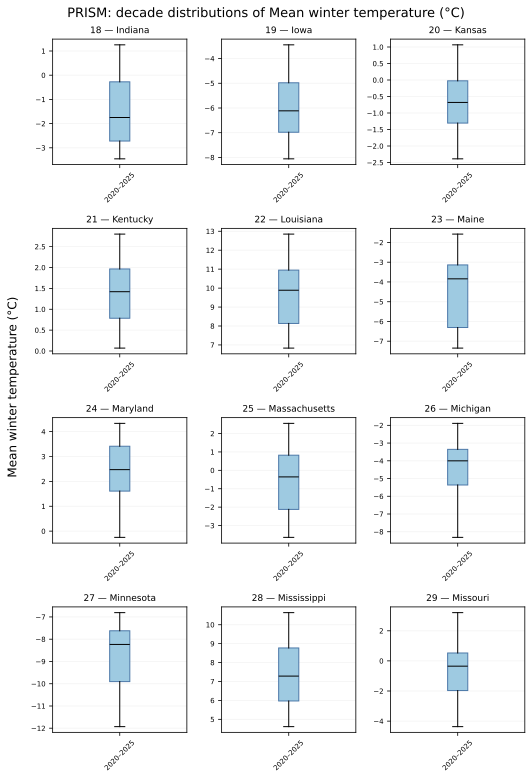

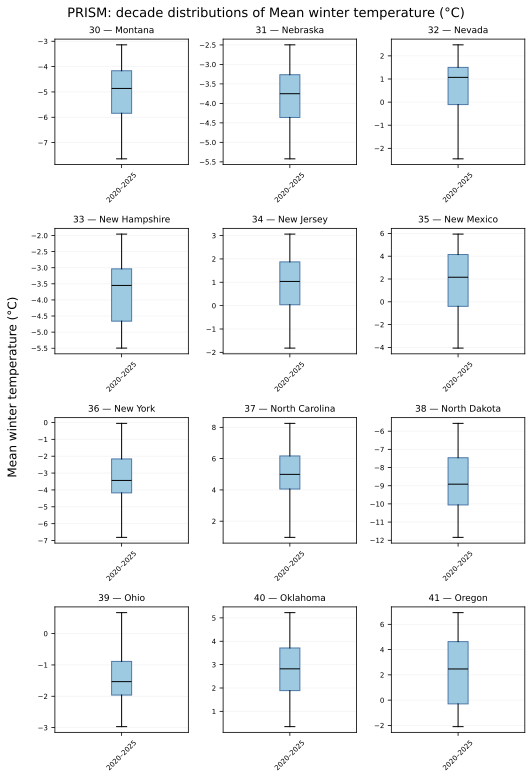

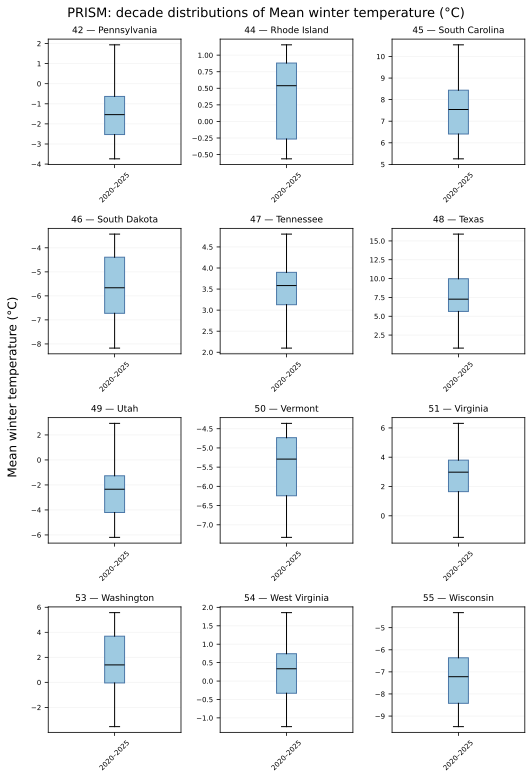

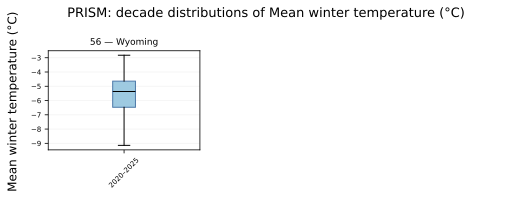

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1/prism_state_decade_distributions_mean_temp_c.pdf


In [11]:
def decade_label(year):
    if 2020 <= int(year) <= 2025:
        return "2020–2025"
    start = (int(year) // 10) * 10
    return f"{start}s"

county_winter["decade"] = county_winter["winter_year"].map(decade_label)

def save_decade_distributions(frame, variable="mean_temp_c", states_per_page=12, n_cols=3):
    states = sorted(frame["state_fips"].dropna().unique())
    decades = sorted(frame["decade"].unique())
    path = FIGURES_DIR / f"{config.name.lower()}_state_decade_distributions_{variable}.pdf"
    with PdfPages(path) as pdf:
        for start in range(0, len(states), states_per_page):
            page_states = states[start:start + states_per_page]
            n_rows = int(np.ceil(len(page_states) / n_cols))
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5, 2.75 * n_rows), squeeze=False)
            for ax, state in zip(axes.flat, page_states):
                sub = frame[frame["state_fips"].eq(state)]
                values = [sub.loc[sub["decade"].eq(decade), variable].dropna() for decade in decades]
                ax.boxplot(values, tick_labels=decades, showfliers=False, patch_artist=True,
                           boxprops={"facecolor":"#9ECAE1", "edgecolor":"#4C78A8"},
                           medianprops={"color":"black"})
                ax.set_title(state_label(state), fontsize=9)
                ax.tick_params(axis="x", rotation=45, labelsize=7)
                ax.tick_params(axis="y", labelsize=7)
                ax.grid(axis="y", alpha=0.15)
            for ax in list(axes.flat)[len(page_states):]:
                ax.axis("off")
            fig.suptitle(f"{config.name}: decade distributions of {variable_label(variable)}", fontsize=13)
            fig.supylabel(variable_label(variable))
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches="tight")
            display_figure_inline(fig)
            plt.close(fig)
    print(f"Saved {path}")
    return path

decade_distribution_path = save_decade_distributions(county_winter)

## 11. Interannual-variability summary

Calculate the standard deviation of county-level mean winter temperature across winters and summarize its distribution nationally and by state. This measure captures general year-to-year variability; it does not specifically identify anomalously warm winters.

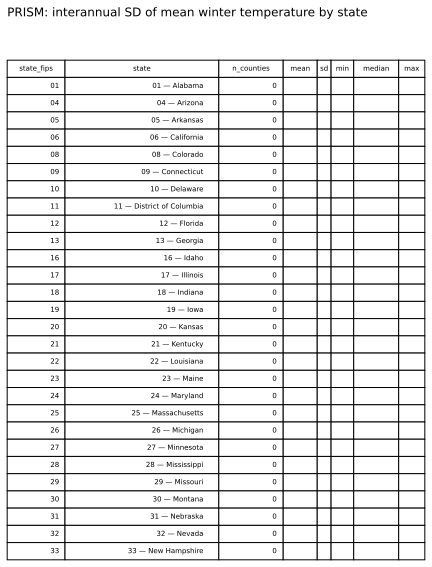

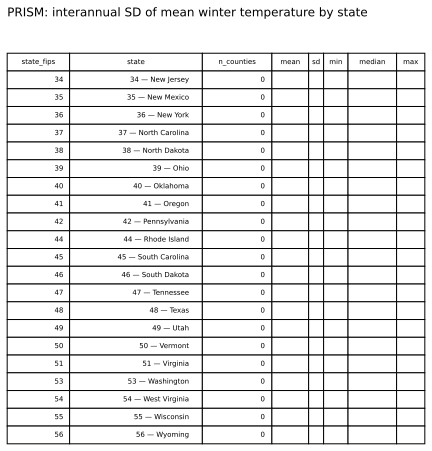

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1/prism_interannual_variability_by_state.pdf


,state_fips,state,n_counties,mean,sd,min,median,max
0,01,01 — Alabama,0,NaN,NaN,NaN,NaN,NaN
1,04,04 — Arizona,0,NaN,NaN,NaN,NaN,NaN
2,05,05 — Arkansas,0,NaN,NaN,NaN,NaN,NaN
3,06,06 — California,0,NaN,NaN,NaN,NaN,NaN
4,08,08 — Colorado,0,NaN,NaN,NaN,NaN,NaN
5,09,09 — Connecticut,0,NaN,NaN,NaN,NaN,NaN
6,10,10 — Delaware,0,NaN,NaN,NaN,NaN,NaN
7,11,11 — District of Columbia,0,NaN,NaN,NaN,NaN,NaN
8,12,12 — Florida,0,NaN,NaN,NaN,NaN,NaN
9,13,13 — Georgia,0,NaN,NaN,NaN,NaN,NaN


In [12]:
if county_winter.empty:
    warnings.warn(
        "The county-winter panel is empty; interannual-variability outputs will have no rows. "
        "Review the completeness diagnostics from Section 2 before interpreting this exhibit."
    )

county_variability = (
    county_winter.groupby(["geoid", "state_fips", "county_name"], as_index=False)
    .agg(
        winter_temp_sd=("mean_temp_c", "std"),
        winter_temp_mean=("mean_temp_c", "mean"),
        n_winters=("mean_temp_c", "count"),
    )
)
county_variability["winter_temp_cv"] = (
    county_variability["winter_temp_sd"] / county_variability["winter_temp_mean"].abs()
)
county_variability.to_csv(
    TABLES_DIR / f"{config.name.lower()}_county_interannual_variability.csv", index=False
)

variability_national = summarize_long(
    county_variability.rename(columns={"winter_temp_sd": "interannual_sd_c"})
)
variability_by_state = (
    county_variability.groupby("state_fips")["winter_temp_sd"]
    .agg(n_counties="count", mean="mean", sd="std", min="min", median="median", max="max")
    .reset_index()
)
variability_by_state["state"] = variability_by_state["state_fips"].map(state_label)
variability_by_state = variability_by_state[
    ["state_fips", "state", "n_counties", "mean", "sd", "min", "median", "max"]
]
variability_by_state.to_csv(
    TABLES_DIR / f"{config.name.lower()}_interannual_variability_by_state.csv", index=False
)
save_table_pdf(
    variability_by_state,
    TABLES_DIR / f"{config.name.lower()}_interannual_variability_by_state.pdf",
    f"{config.name}: interannual SD of mean winter temperature by state",
    rows_per_page=28,
)
display(variability_by_state)

## 12. Interannual-variability choropleth

Map the standard deviation of mean winter temperature across winters by county. The purpose is to identify regions with high general interannual variability and distinguish that concept from long-run warming and anomalous-warm-winter frequency.

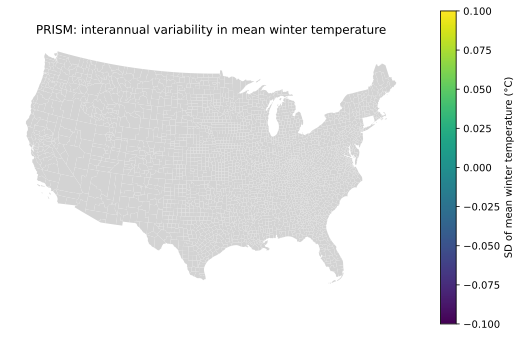

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1/prism_interannual_variability_choropleth.pdf


In [13]:
COUNTY_GEOMETRY_CANDIDATES = [
    REPO_ROOT / "dataRAW" / "shapefiles" / "cb_2023_us_county_20m.shp",
    REPO_ROOT / "dataRAW" / "cb_2023_us_county_20m.shp",
]
CENSUS_COUNTY_URL = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"

def load_county_geometry():
    try:
        import geopandas as gpd
    except ImportError as exc:
        raise ImportError(
            "Tier 1 choropleths require GeoPandas. Install the project dependencies "
            "in this notebook kernel with: %pip install -r ../requirements.txt "
            "Then restart the kernel and rerun the notebook."
        ) from exc
    local = next((path for path in COUNTY_GEOMETRY_CANDIDATES if path.exists()), None)
    source = local if local is not None else CENSUS_COUNTY_URL
    geometry = gpd.read_file(source)
    geoid_col = next((c for c in ("GEOID", "GEOID20", "geoid") if c in geometry), None)
    if geoid_col is None:
        raise KeyError("County geometry does not contain a recognized GEOID column.")
    geometry["geoid"] = geometry[geoid_col].astype(str).str.zfill(5)
    return geometry[["geoid", "geometry"]]

county_geometry = load_county_geometry()
variability_map = county_geometry.merge(
    county_variability[["geoid", "winter_temp_sd"]], on="geoid", how="inner", validate="one_to_one"
)
variability_map = variability_map.to_crs("EPSG:5070")
fig, ax = plt.subplots(figsize=(7.5, 4.8))
variability_map.plot(
    column="winter_temp_sd", cmap="viridis", linewidth=0,
    legend=True, legend_kwds={"label": "SD of mean winter temperature (°C)"},
    missing_kwds={"color": "lightgrey"}, ax=ax,
)
ax.set_title(f"{config.name}: interannual variability in mean winter temperature")
ax.axis("off")
fig.tight_layout()
interannual_variability_map_path = save_figure_pdf(
    fig, f"{config.name.lower()}_interannual_variability_choropleth.pdf"
)

## 13. Tier 1 QA findings and flagged observations

Summarize the main QA findings in plain language. List implausible values, unusual counties or winters, merge or coverage issues, and decisions requiring follow-up. Distinguish confirmed data problems from genuine but unusual weather observations.

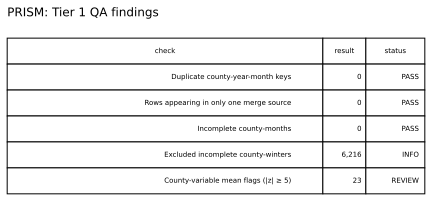

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1/prism_tier1_qa_findings.pdf


,check,result,status
0,Duplicate county-year-month keys,0,PASS
1,Rows appearing in only one merge source,0,PASS
2,Incomplete county-months,0,PASS
3,Excluded incomplete county-winters,6216,INFO
4,County-variable mean flags (|z| ≥ 5),23,REVIEW


Tier 1 outputs complete.
Tables: /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/tables/weather/tier1
Figures: /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier1


In [14]:
qa_findings = [
    {
        "check": "Duplicate county-year-month keys",
        "result": load_diagnostics["duplicate_monthly_keys"] + load_diagnostics["duplicate_derived_keys"],
        "status": "PASS" if not (load_diagnostics["duplicate_monthly_keys"] + load_diagnostics["duplicate_derived_keys"]) else "REVIEW",
    },
    {
        "check": "Rows appearing in only one merge source",
        "result": load_diagnostics["monthly_only_rows"] + load_diagnostics["derived_only_rows"],
        "status": "PASS" if not (load_diagnostics["monthly_only_rows"] + load_diagnostics["derived_only_rows"]) else "REVIEW",
    },
    {
        "check": "Incomplete county-months",
        "result": load_diagnostics["incomplete_months"],
        "status": "PASS" if not load_diagnostics["incomplete_months"] else "REVIEW",
    },
    {
        "check": "Excluded incomplete county-winters",
        "result": winter_diagnostics["excluded_incomplete_county_winters"],
        "status": "INFO",
    },
    {
        "check": f"County-variable mean flags (|z| ≥ {OUTLIER_Z_THRESHOLD:g})",
        "result": len(flagged_counties),
        "status": "REVIEW" if len(flagged_counties) else "PASS",
    },
]
qa_findings = pd.DataFrame(qa_findings)
qa_findings.to_csv(TABLES_DIR / f"{config.name.lower()}_tier1_qa_findings.csv", index=False)
save_table_pdf(
    qa_findings,
    TABLES_DIR / f"{config.name.lower()}_tier1_qa_findings.pdf",
    f"{config.name}: Tier 1 QA findings",
)
display(qa_findings)

print("Tier 1 outputs complete.")
print(f"Tables: {TABLES_DIR}")
print(f"Figures: {FIGURES_DIR}")

# Tier 2 — Polished explanatory exhibits

Tier 2 communicates the two weather forces central to the project's causal story: long-run winter warming and short-run anomalously warm winter shocks. These exhibits should use publication-quality labels, units, annotations, legends, colorblind-accessible palettes, and vector output where possible.

## 14. National long-run warming exhibit

Present a polished national figure showing annual mean winter temperature and its long-run trend over the complete-winter sample. Clearly identify the geographic weighting convention and retain annual observations so anomalous winters remain visible.

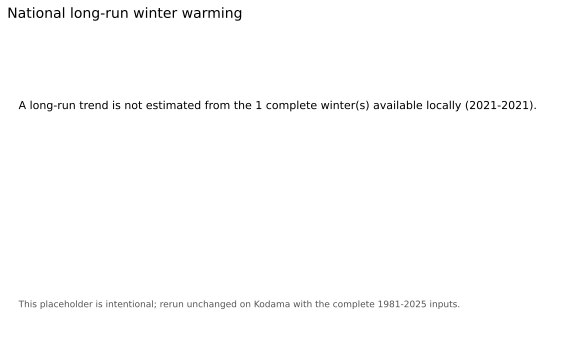

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_national_long_run_warming.pdf


In [15]:
# Tier 2 outputs are kept separate from Tier 1 QA artifacts.
TIER2_TABLES_DIR = REPO_ROOT / "tables" / "weather" / "tier2"
TIER2_FIGURES_DIR = REPO_ROOT / "figures" / "weather" / "tier2"
TIER2_TABLES_DIR.mkdir(parents=True, exist_ok=True)
TIER2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
tier2_outputs = []

TIER2_COLORS = {"annual": "#0072B2", "trend": "#D55E00", "warm": "#B2182B"}

def save_tier2_figure(fig, filename):
    path = TIER2_FIGURES_DIR / filename
    fig.savefig(path, format="pdf", bbox_inches="tight", metadata={"Creator": "09_descriptive_weather_full.ipynb"})
    display_figure_inline(fig)
    plt.close(fig)
    tier2_outputs.append(path)
    print(f"Saved {path}")
    return path

def save_tier2_placeholder(filename, title, message):
    """Create a vector diagnostic exhibit when the local sample is too short."""
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ax.axis("off"); ax.set_title(title, loc="left", fontsize=14, pad=18)
    ax.text(0.02, 0.78, message, transform=ax.transAxes, ha="left", va="top", fontsize=11, wrap=True)
    ax.text(0.02, 0.08, "This placeholder is intentional; rerun unchanged on Kodama with the complete 1981-2025 inputs.", transform=ax.transAxes, fontsize=9, color="#555555")
    fig.tight_layout(); return save_tier2_figure(fig, filename)

national_winter = county_winter.groupby("winter_year", as_index=False).agg(
    mean_temp_c=("mean_temp_c", "mean"), n_counties=("geoid", "nunique")
)
FULL_LONG_RUN_SAMPLE = len(national_winter) >= 30
if not FULL_LONG_RUN_SAMPLE:
    national_warming_path = save_tier2_placeholder(f"{config.name.lower()}_national_long_run_warming.pdf", "National long-run winter warming", f"A long-run trend is not estimated from the {len(national_winter)} complete winter(s) available locally ({winter_diagnostics['first_complete_winter']}-{winter_diagnostics['last_complete_winter']}).")
else:
    trend = _linear_trend(national_winter["winter_year"], national_winter["mean_temp_c"])
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ax.plot(national_winter["winter_year"], national_winter["mean_temp_c"], color=TIER2_COLORS["annual"], lw=1.5, marker="o", ms=3.5, label="Annual county mean")
    change = trend[2] * (national_winter["winter_year"].max() - national_winter["winter_year"].min())
    ax.plot(trend[0], trend[1], color=TIER2_COLORS["trend"], lw=2.5, label=f"Linear trend ({trend[2] * 10:+.2f}°C/decade)")
    ax.text(0.02, 0.05, f"Fitted change across sample: {change:+.2f}°C", transform=ax.transAxes, fontsize=9)
    ax.set(title="U.S. winters have warmed since the early 1980s", xlabel="Winter year (December-February)", ylabel="Mean winter temperature (°C)")
    ax.text(0, -0.22, f"Source: {config.name}. Unweighted mean across counties; complete DJF winters only.", transform=ax.transAxes, fontsize=8, color="#555555")
    ax.grid(axis="y", alpha=0.2); ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, ncol=2)
    fig.tight_layout(); national_warming_path = save_tier2_figure(fig, f"{config.name.lower()}_national_long_run_warming.pdf")

## 15. State long-run warming exhibit

Present polished state-level small multiples showing geographic heterogeneity in winter-temperature trends. Consider displaying trend slopes or early-to-recent changes if annual series make the panels too dense.

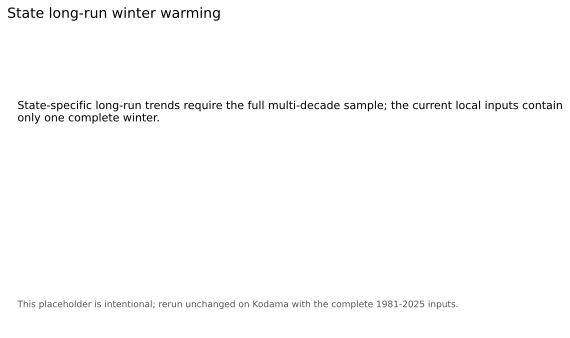

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_state_long_run_warming.pdf


In [16]:
state_annual = county_winter.groupby(["state_fips", "winter_year"], as_index=False)["mean_temp_c"].mean()
states = sorted(state_annual["state_fips"].dropna().unique())
state_warming_path = TIER2_FIGURES_DIR / f"{config.name.lower()}_state_long_run_warming.pdf"
if not FULL_LONG_RUN_SAMPLE:
    state_warming_path = save_tier2_placeholder(state_warming_path.name, "State long-run winter warming", "State-specific long-run trends require the full multi-decade sample; the current local inputs contain only one complete winter.")
else:
 with PdfPages(state_warming_path, metadata={"Creator": "09_descriptive_weather_full.ipynb"}) as pdf:
    for start in range(0, len(states), 12):
        page_states = states[start:start + 12]
        fig, axes = plt.subplots(4, 3, figsize=(8.2, 9.5), sharex=True, squeeze=False)
        for ax, state in zip(axes.flat, page_states):
            annual = state_annual[state_annual["state_fips"].eq(state)]
            state_trend = _linear_trend(annual["winter_year"], annual["mean_temp_c"])
            ax.plot(annual["winter_year"], annual["mean_temp_c"], color=TIER2_COLORS["annual"], lw=1)
            slope_text = "trend unavailable"
            if state_trend is not None:
                ax.plot(state_trend[0], state_trend[1], color=TIER2_COLORS["trend"], lw=1.8)
                slope_text = f"{state_trend[2] * 10:+.2f}°C/decade"
            ax.set_title(f"{STATE_FIPS_TO_NAME.get(str(state).zfill(2), state)}\n{slope_text}", fontsize=9)
            ax.grid(axis="y", alpha=0.15); ax.tick_params(labelsize=7); ax.spines[["top", "right"]].set_visible(False)
        for ax in list(axes.flat)[len(page_states):]: ax.axis("off")
        fig.suptitle("Winter-temperature trends vary across states", fontsize=14)
        fig.supxlabel("Winter year"); fig.supylabel("Unweighted county mean (°C)")
        fig.text(0.01, 0.005, f"Source: {config.name}; complete DJF winters. Orange lines show state-specific linear trends.", fontsize=8, color="#555555")
        fig.tight_layout(rect=[0.02, 0.025, 1, 0.97]); pdf.savefig(fig, bbox_inches="tight"); display_figure_inline(fig); plt.close(fig)
 if state_warming_path not in tier2_outputs: tier2_outputs.append(state_warming_path)
 print(f"Saved {state_warming_path}")

## 16. Early-versus-recent winter-temperature choropleths

Map county mean winter temperature for a clearly defined early period and recent period. Use identical classification rules and color limits so that the two maps are directly comparable. Document the selected periods.

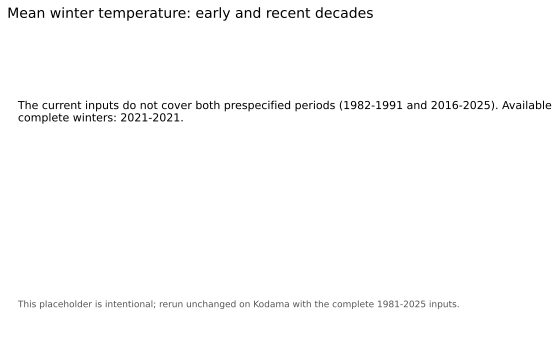

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_winter_temperature_early_vs_recent.pdf


In [17]:
# Ten-winter windows balance temporal contrast with resistance to single-winter noise.
EARLY_PERIOD = (1982, 1991)
RECENT_PERIOD = (2016, 2025)

def period_mean(frame, variable, period, output_name):
    lo, hi = period
    return (frame[frame["winter_year"].between(lo, hi)].groupby("geoid", as_index=False)
            .agg(**{output_name: (variable, "mean")}, n_winters=(variable, "count")))

early_temp = period_mean(county_winter, "mean_temp_c", EARLY_PERIOD, "early_temp_c")
recent_temp = period_mean(county_winter, "mean_temp_c", RECENT_PERIOD, "recent_temp_c")
temperature_periods = early_temp.merge(recent_temp, on="geoid", suffixes=("_early", "_recent"), validate="one_to_one")
temperature_periods.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_county_temperature_early_recent.csv", index=False)
temperature_map = county_geometry.merge(temperature_periods, on="geoid", how="inner", validate="one_to_one").to_crs("EPSG:5070")
if temperature_map.empty:
    early_recent_map_path = save_tier2_placeholder(f"{config.name.lower()}_winter_temperature_early_vs_recent.pdf", "Mean winter temperature: early and recent decades", f"The current inputs do not cover both prespecified periods ({EARLY_PERIOD[0]}-{EARLY_PERIOD[1]} and {RECENT_PERIOD[0]}-{RECENT_PERIOD[1]}). Available complete winters: {winter_diagnostics['first_complete_winter']}-{winter_diagnostics['last_complete_winter']}.")
else:
    common_min = float(temperature_map[["early_temp_c", "recent_temp_c"]].min().min())
    common_max = float(temperature_map[["early_temp_c", "recent_temp_c"]].max().max())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, column, period, title in zip(axes, ["early_temp_c", "recent_temp_c"], [EARLY_PERIOD, RECENT_PERIOD], ["Early period", "Recent period"]):
        temperature_map.plot(column=column, cmap="coolwarm", vmin=common_min, vmax=common_max, linewidth=0, ax=ax)
        ax.set_title(f"{title}: {period[0]}-{period[1]}", fontsize=11); ax.axis("off")
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(common_min, common_max)); sm.set_array([])
    fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.06, pad=0.03, label="Mean winter temperature (°C)")
    fig.suptitle("Mean winter temperature: early and recent decades", fontsize=14)
    fig.text(0.01, 0.01, f"Source: {config.name}; county means over complete DJF winters. Both panels use identical color limits.", fontsize=8, color="#555555")
    fig.subplots_adjust(bottom=0.15, top=0.88, wspace=0.02)
    early_recent_map_path = save_tier2_figure(fig, f"{config.name.lower()}_winter_temperature_early_vs_recent.pdf")

## 17. Change-in-winter-temperature choropleth

Map the county-level change in mean winter temperature between the early and recent periods. This exhibit should directly identify which places experienced the greatest long-run winter warming.

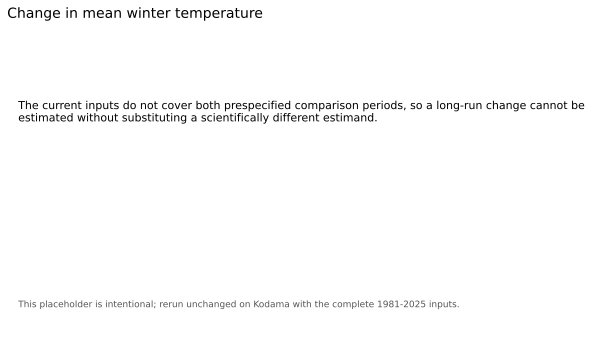

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_winter_temperature_change.pdf


In [18]:
temperature_periods["change_temp_c"] = temperature_periods["recent_temp_c"] - temperature_periods["early_temp_c"]
change_map = county_geometry.merge(temperature_periods[["geoid", "change_temp_c"]], on="geoid", how="inner", validate="one_to_one").to_crs("EPSG:5070")
if change_map.empty:
    warming_change_map_path = save_tier2_placeholder(f"{config.name.lower()}_winter_temperature_change.pdf", "Change in mean winter temperature", "The current inputs do not cover both prespecified comparison periods, so a long-run change cannot be estimated without substituting a scientifically different estimand.")
else:
    change_limit = float(np.nanmax(np.abs(change_map["change_temp_c"])))
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    change_map.plot(column="change_temp_c", cmap="RdBu_r", vmin=-change_limit, vmax=change_limit, linewidth=0, legend=True, legend_kwds={"label": f"Change in mean winter temperature (°C): {RECENT_PERIOD[0]}-{RECENT_PERIOD[1]} minus {EARLY_PERIOD[0]}-{EARLY_PERIOD[1]}", "shrink": 0.75}, ax=ax)
    ax.set_title("Where U.S. winters have warmed the most", fontsize=14); ax.axis("off")
    fig.text(0.01, 0.01, f"Source: {config.name}; county means over complete DJF winters. Diverging scale is centered at zero.", fontsize=8, color="#555555")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    warming_change_map_path = save_tier2_figure(fig, f"{config.name.lower()}_winter_temperature_change.pdf")

## 18. Extreme-cold-day choropleth

Map the mean annual number of winter days with minimum temperature below 0°F, or the change in that count between the early and recent periods. Label this measure **extreme-cold-day count**, not Winter Severity Index. A complete Wisconsin-style WSI would require additional components such as deep-snow days.

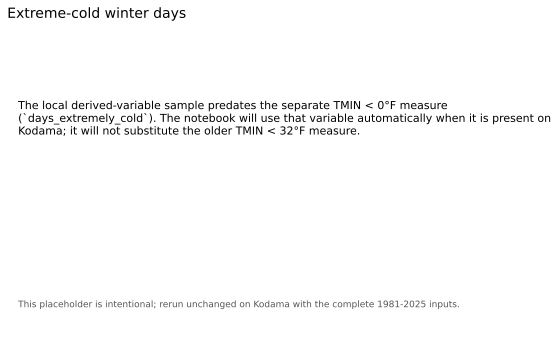

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_extreme_cold_day_count.pdf


In [19]:
if "days_extremely_cold" not in county_winter:
    extreme_cold = pd.DataFrame(columns=["geoid", "mean_extreme_cold_days", "n_winters"])
    extreme_cold_map_path = save_tier2_placeholder(f"{config.name.lower()}_extreme_cold_day_count.pdf", "Extreme-cold winter days", "The local derived-variable sample predates the separate TMIN < 0°F measure (`days_extremely_cold`). The notebook will use that variable automatically when it is present on Kodama; it will not substitute the older TMIN < 32°F measure.")
else:
    extreme_cold = (county_winter.groupby("geoid", as_index=False).agg(mean_extreme_cold_days=("days_extremely_cold", "mean"), n_winters=("days_extremely_cold", "count")))
    extreme_cold_map = county_geometry.merge(extreme_cold, on="geoid", how="inner", validate="one_to_one").to_crs("EPSG:5070")
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    extreme_cold_map.plot(column="mean_extreme_cold_days", cmap="cividis_r", linewidth=0, legend=True, legend_kwds={"label": "Mean extreme-cold-day count per winter", "shrink": 0.75}, ax=ax)
    ax.set_title("Extreme-cold winter days are concentrated in the northern U.S.", fontsize=13); ax.axis("off")
    fig.text(0.01, 0.01, f"Source: {config.name}; days with daily minimum temperature below 0°F, averaged over complete DJF winters. This is not a full Winter Severity Index.", fontsize=8, color="#555555")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    extreme_cold_map_path = save_tier2_figure(fig, f"{config.name.lower()}_extreme_cold_day_count.pdf")
extreme_cold.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_county_extreme_cold_days.csv", index=False)

## 19. Define anomalously warm winters

Specify and justify the provisional anomaly definition before producing anomaly exhibits. Document the winter metric, county-specific reference distribution, treatment of the long-run trend, threshold, minimum coverage, and whether results are expressed as counts or shares. Candidate definitions require Eyal's confirmation before being treated as final.

In [20]:
ANOMALY_SD_THRESHOLD = 1.5
ANOMALY_MIN_WINTERS = 30
ANOMALY_DEFINITION_STATUS = "PROVISIONAL - requires Eyal's confirmation"

def classify_warm_anomalies(frame, threshold=ANOMALY_SD_THRESHOLD, min_winters=ANOMALY_MIN_WINTERS):
    """Flag warm shocks relative to each county's detrended full-sample distribution."""
    pieces = []
    for geoid, county in frame.groupby("geoid"):
        county = county.dropna(subset=["winter_year", "mean_temp_c"]).sort_values("winter_year").copy()
        if len(county) < min_winters or county["winter_year"].nunique() < 2:
            continue
        slope, intercept = np.polyfit(county["winter_year"], county["mean_temp_c"], 1)
        county["fitted_temp_c"] = intercept + slope * county["winter_year"]
        county["detrended_anomaly_c"] = county["mean_temp_c"] - county["fitted_temp_c"]
        residual_sd = county["detrended_anomaly_c"].std(ddof=1)
        county["anomaly_z"] = county["detrended_anomaly_c"] / residual_sd if residual_sd > 0 else np.nan
        county["anomalously_warm"] = county["anomaly_z"].gt(threshold)
        county["county_trend_c_per_decade"] = slope * 10
        pieces.append(county)
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()

warm_anomalies = classify_warm_anomalies(county_winter)
warm_anomalies.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_county_winter_warm_anomalies_provisional.csv", index=False)
anomaly_definition = pd.DataFrame([{"status": ANOMALY_DEFINITION_STATUS, "metric": "county-winter mean temperature", "reference_distribution": "county-specific full sample", "trend_treatment": "linear county trend removed", "threshold": f"> {ANOMALY_SD_THRESHOLD} residual SD", "minimum_complete_winters": ANOMALY_MIN_WINTERS, "frequency_measure": "share of eligible winters"}])
anomaly_definition.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_anomaly_definition_provisional.csv", index=False)
display(anomaly_definition)

,status,metric,reference_distribution,trend_treatment,threshold,minimum_complete_winters,frequency_measure
0,PROVISIONAL - requires Eyal's confirmation,county-winter mean temperature,county-specific full sample,linear county trend removed,> 1.5 residual SD,30,share of eligible winters


## 20. Anomalous-warm-winter frequency choropleth

Map the number or share of winters classified as anomalously warm within each county. This exhibit captures the geographic concentration of short-run warm shocks rather than general variability or long-run warming. Clearly label the anomaly definition as provisional or confirmed.

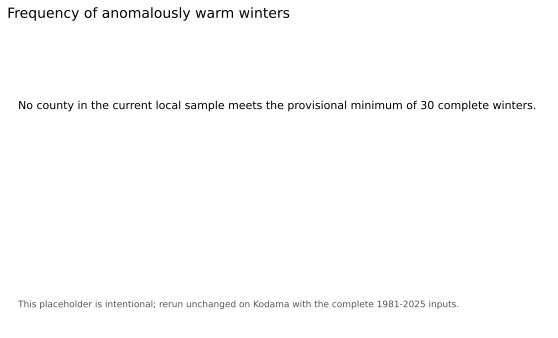

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_anomalous_warm_winter_frequency_provisional.pdf


In [21]:
anomaly_frequency = (warm_anomalies.groupby(["geoid", "state_fips", "county_name"], as_index=False).agg(anomalous_warm_winters=("anomalously_warm", "sum"), eligible_winters=("anomalously_warm", "size"))) if not warm_anomalies.empty else pd.DataFrame(columns=["geoid", "state_fips", "county_name", "anomalous_warm_winters", "eligible_winters", "anomalous_warm_share"])
if not anomaly_frequency.empty: anomaly_frequency["anomalous_warm_share"] = anomaly_frequency["anomalous_warm_winters"] / anomaly_frequency["eligible_winters"]
anomaly_frequency.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_county_anomalous_warm_winter_frequency_provisional.csv", index=False)
anomaly_map = county_geometry.merge(anomaly_frequency, on="geoid", how="inner", validate="one_to_one").to_crs("EPSG:5070")
if anomaly_map.empty:
    anomaly_frequency_map_path = save_tier2_placeholder(f"{config.name.lower()}_anomalous_warm_winter_frequency_provisional.pdf", "Frequency of anomalously warm winters", f"No county in the current local sample meets the provisional minimum of {ANOMALY_MIN_WINTERS} complete winters.")
else:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    anomaly_map.plot(column="anomalous_warm_share", cmap="YlOrRd", vmin=0, linewidth=0, legend=True, legend_kwds={"label": "Share of winters classified as anomalously warm", "format": "%.2f", "shrink": 0.75}, ax=ax)
    ax.set_title("Frequency of anomalously warm winters", fontsize=14); ax.axis("off")
    fig.text(0.01, 0.01, f"{ANOMALY_DEFINITION_STATUS}. County-specific detrended residual > {ANOMALY_SD_THRESHOLD} SD; at least {ANOMALY_MIN_WINTERS} complete winters.", fontsize=8, color="#555555")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    anomaly_frequency_map_path = save_tier2_figure(fig, f"{config.name.lower()}_anomalous_warm_winter_frequency_provisional.pdf")

## 21. Anomalous-winter time-series exhibit

Show the national or state-level frequency of anomalously warm county-winters over time. Use this figure to distinguish unusual short-run shocks from the gradual long-run warming trend.

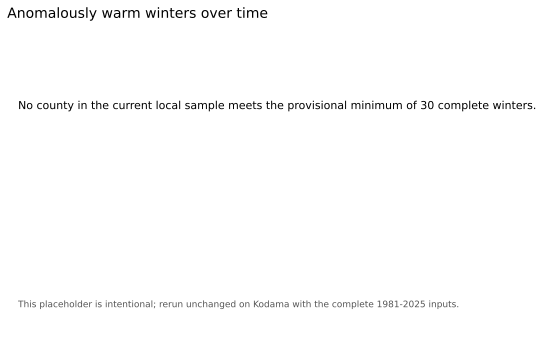

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_anomalous_warm_winter_time_series_provisional.pdf


In [22]:
anomaly_time = (warm_anomalies.groupby("winter_year", as_index=False).agg(anomalous_counties=("anomalously_warm", "sum"), eligible_counties=("anomalously_warm", "size"))) if not warm_anomalies.empty else pd.DataFrame(columns=["winter_year", "anomalous_counties", "eligible_counties", "anomalous_county_share"])
if not anomaly_time.empty: anomaly_time["anomalous_county_share"] = anomaly_time["anomalous_counties"] / anomaly_time["eligible_counties"]
anomaly_time.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_annual_anomalous_warm_winter_frequency_provisional.csv", index=False)
if anomaly_time.empty:
    anomaly_time_path = save_tier2_placeholder(f"{config.name.lower()}_anomalous_warm_winter_time_series_provisional.pdf", "Anomalously warm winters over time", f"No county in the current local sample meets the provisional minimum of {ANOMALY_MIN_WINTERS} complete winters.")
else:
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ax.bar(anomaly_time["winter_year"], anomaly_time["anomalous_county_share"] * 100, color=TIER2_COLORS["annual"], width=0.8)
    ax.axhline(100 * warm_anomalies["anomalously_warm"].mean(), color=TIER2_COLORS["trend"], lw=2, ls="--", label="Full-sample county-winter share")
    ax.set(title="Anomalously warm winters are episodic national shocks", xlabel="Winter year (December-February)", ylabel="Counties anomalously warm (%)", ylim=(0, None))
    ax.grid(axis="y", alpha=0.2); ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False)
    ax.text(0, -0.22, f"{ANOMALY_DEFINITION_STATUS}. Detrending separates short-run shocks from gradual county warming.", transform=ax.transAxes, fontsize=8, color="#555555")
    fig.tight_layout()
    anomaly_time_path = save_tier2_figure(fig, f"{config.name.lower()}_anomalous_warm_winter_time_series_provisional.pdf")

## 22. Polished decade-distribution exhibit

Select the most informative national, regional, or state examples from the Tier 1 decade-distribution plots. Use them to demonstrate whether climate change shifts the location, spread, or shape of the winter-temperature distribution.

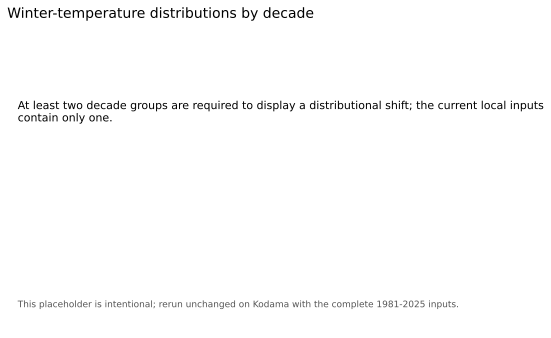

Saved /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2/prism_national_winter_temperature_distributions_by_decade.pdf


In [23]:
decade_order = [d for d in ["1980s", "1990s", "2000s", "2010s", "2020–2025"] if d in set(county_winter["decade"])]
decade_values = [county_winter.loc[county_winter["decade"].eq(d), "mean_temp_c"].dropna().values for d in decade_order]
if len(decade_order) < 2:
    decade_polished_path = save_tier2_placeholder(f"{config.name.lower()}_national_winter_temperature_distributions_by_decade.pdf", "Winter-temperature distributions by decade", "At least two decade groups are required to display a distributional shift; the current local inputs contain only one.")
else:
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    violins = ax.violinplot(decade_values, positions=np.arange(len(decade_order)), showmeans=False, showmedians=True, showextrema=False, widths=0.85)
    for body in violins["bodies"]: body.set_facecolor(TIER2_COLORS["annual"]); body.set_edgecolor("white"); body.set_alpha(0.75)
    violins["cmedians"].set_color("black"); violins["cmedians"].set_linewidth(2)
    ax.set_xticks(np.arange(len(decade_order)), decade_order); ax.set(title="The distribution of county winter temperatures has shifted warmer", xlabel="Winter period", ylabel="County-winter mean temperature (°C)")
    ax.grid(axis="y", alpha=0.2); ax.spines[["top", "right"]].set_visible(False)
    ax.text(0, -0.20, f"Source: {config.name}; all complete county-winters. Black bars mark medians; violin width shows density.", transform=ax.transAxes, fontsize=8, color="#555555")
    fig.tight_layout(); decade_polished_path = save_tier2_figure(fig, f"{config.name.lower()}_national_winter_temperature_distributions_by_decade.pdf")

## 23. Optional targeted PRISM–ERA5 comparison

If needed, compare selected PRISM and ERA5 measures to assess robustness and agreement. Prioritize targeted comparisons over duplicating the complete PRISM exhibit suite.

In [24]:
# ERA5 is a targeted robustness check only. Skip cleanly when the local checkout lacks full ERA5 inputs.
era5_comparison_path = None
if ERA5_CONFIG.monthly_path.exists() and ERA5_CONFIG.derived_path.exists():
    era5_monthly, _ = load_weather_panel(ERA5_CONFIG)
    era5_winter, _, _ = construct_county_winter_panel(era5_monthly)
    prism_national = county_winter.groupby("winter_year", as_index=False)["mean_temp_c"].mean().rename(columns={"mean_temp_c": "PRISM"})
    era5_national = era5_winter.groupby("winter_year", as_index=False)["mean_temp_c"].mean().rename(columns={"mean_temp_c": "ERA5"})
    comparison = prism_national.merge(era5_national, on="winter_year", validate="one_to_one")
    comparison.to_csv(TIER2_TABLES_DIR / "prism_era5_national_winter_temperature_comparison.csv", index=False)
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    ax.plot(comparison["winter_year"], comparison["PRISM"], label="PRISM", color=TIER2_COLORS["annual"], lw=1.7)
    ax.plot(comparison["winter_year"], comparison["ERA5"], label="ERA5", color=TIER2_COLORS["trend"], lw=1.5)
    ax.set(title="PRISM and ERA5 national winter-temperature comparison", xlabel="Winter year", ylabel="Unweighted county mean (°C)"); ax.legend(frameon=False); ax.grid(axis="y", alpha=0.2); ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout(); era5_comparison_path = save_tier2_figure(fig, "prism_era5_national_winter_temperature_comparison.pdf")
else:
    print("Skipped optional PRISM-ERA5 comparison: full ERA5 monthly and derived files are not both present.")

Skipped optional PRISM-ERA5 comparison: full ERA5 monthly and derived files are not both present.


## 24. Exhibit index, output manifest, and decisions for Eyal

End the report with an ordered exhibit index and a manifest of saved tables and figures. Summarize unresolved methodological choices—especially anomaly definition, weighting, comparison periods, and any questionable observations—for efficient PI review.

In [25]:
exhibit_index = pd.DataFrame([
    {"order": 1, "section": 14, "exhibit": "National long-run warming", "path": national_warming_path},
    {"order": 2, "section": 15, "exhibit": "State long-run warming", "path": state_warming_path},
    {"order": 3, "section": 16, "exhibit": "Early versus recent temperature", "path": early_recent_map_path},
    {"order": 4, "section": 17, "exhibit": "Temperature change", "path": warming_change_map_path},
    {"order": 5, "section": 18, "exhibit": "Extreme-cold-day count", "path": extreme_cold_map_path},
    {"order": 6, "section": 20, "exhibit": "Warm-anomaly frequency (provisional)", "path": anomaly_frequency_map_path},
    {"order": 7, "section": 21, "exhibit": "Warm-anomaly time series (provisional)", "path": anomaly_time_path},
    {"order": 8, "section": 22, "exhibit": "Temperature distributions by decade", "path": decade_polished_path},
])
if era5_comparison_path is not None:
    exhibit_index.loc[len(exhibit_index)] = [9, 23, "Targeted PRISM-ERA5 comparison", era5_comparison_path]
exhibit_index["path"] = exhibit_index["path"].map(str)
exhibit_index.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_tier2_exhibit_index.csv", index=False)

manifest_rows = [{"artifact_type": "figure", "path": str(path)} for path in tier2_outputs]
manifest_rows += [{"artifact_type": "table", "path": str(path)} for path in sorted(TIER2_TABLES_DIR.glob("*"))]
output_manifest = pd.DataFrame(manifest_rows).drop_duplicates().sort_values(["artifact_type", "path"])
output_manifest.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_tier2_output_manifest.csv", index=False)

decisions_for_eyal = pd.DataFrame([
    {"decision": "Anomaly definition", "current_choice": f"Detrended county residual > {ANOMALY_SD_THRESHOLD} SD; minimum {ANOMALY_MIN_WINTERS} winters", "status": "CONFIRM"},
    {"decision": "Geographic weighting", "current_choice": "Unweighted mean across counties", "status": "CONFIRM"},
    {"decision": "Comparison periods", "current_choice": f"{EARLY_PERIOD[0]}-{EARLY_PERIOD[1]} versus {RECENT_PERIOD[0]}-{RECENT_PERIOD[1]}", "status": "CONFIRM"},
    {"decision": "Extreme-cold exhibit", "current_choice": "Mean days with TMIN < 0°F; not labeled WSI", "status": "DOCUMENTED"},
    {"decision": "ERA5 robustness exhibit", "current_choice": "Targeted national comparison only when full inputs exist", "status": "OPTIONAL"},
])
decisions_for_eyal.to_csv(TIER2_TABLES_DIR / f"{config.name.lower()}_tier2_decisions_for_eyal.csv", index=False)
display(exhibit_index); display(output_manifest); display(decisions_for_eyal)
print(f"Tier 2 complete: {len(tier2_outputs)} vector-PDF exhibit files in {TIER2_FIGURES_DIR}")

,order,section,exhibit,path
0,1,14,National long-run warming,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
1,2,15,State long-run warming,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
2,3,16,Early versus recent temperature,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
3,4,17,Temperature change,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
4,5,18,Extreme-cold-day count,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
5,6,20,Warm-anomaly frequency (provisional),/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
6,7,21,Warm-anomaly time series (provisional),/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
7,8,22,Temperature distributions by decade,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...


,artifact_type,path
5,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
6,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
4,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
0,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
7,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
1,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
3,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
2,figure,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
8,table,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...
9,table,/Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - ...


,decision,current_choice,status
0,Anomaly definition,Detrended county residual > 1.5 SD; minimum 30...,CONFIRM
1,Geographic weighting,Unweighted mean across counties,CONFIRM
2,Comparison periods,1982-1991 versus 2016-2025,CONFIRM
3,Extreme-cold exhibit,Mean days with TMIN < 0°F; not labeled WSI,DOCUMENTED
4,ERA5 robustness exhibit,Targeted national comparison only when full in...,OPTIONAL


Tier 2 complete: 8 vector-PDF exhibit files in /Users/wendyhtw/Documents/CAPP ('25-'27)/Q4 - Summer'26/EPIC/Repos/collisions-and-climate/figures/weather/tier2
